# PREPARACIÓN PARA IMPUTACIÓN DE VARIABLES

Se realiza una preparación previa mediante la extracción de la información de la base de datos en formato CSV y la importación de todas las librerías necesarias para el desarrollo de este notebook de imputación de datos.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
import warnings
from pathlib import Path
from sklearn.preprocessing import OrdinalEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

pd.set_option("display.max_columns", None)
bd = pd.read_csv("/content/01_energia_processed(5).csv")

# FASE 1: ANÁLISIS DE MECANISMOS DE AUSENCIA

En esta fase se usarán los gráficos de missingno y tablas extra que representen cómo se distribuyen y aparecen los nulos a lo largo de toda la distribución. Esto permitirá tener una visión general de los valores nulos para su posterior imputación y corrección en fases posteriores.

Visualización: Frecuencia de Valores Faltantes (msno.bar)



**Análisis:**
- **Resumen:** Este gráfico cuantifica la cantidad de datos disponibles por variable.

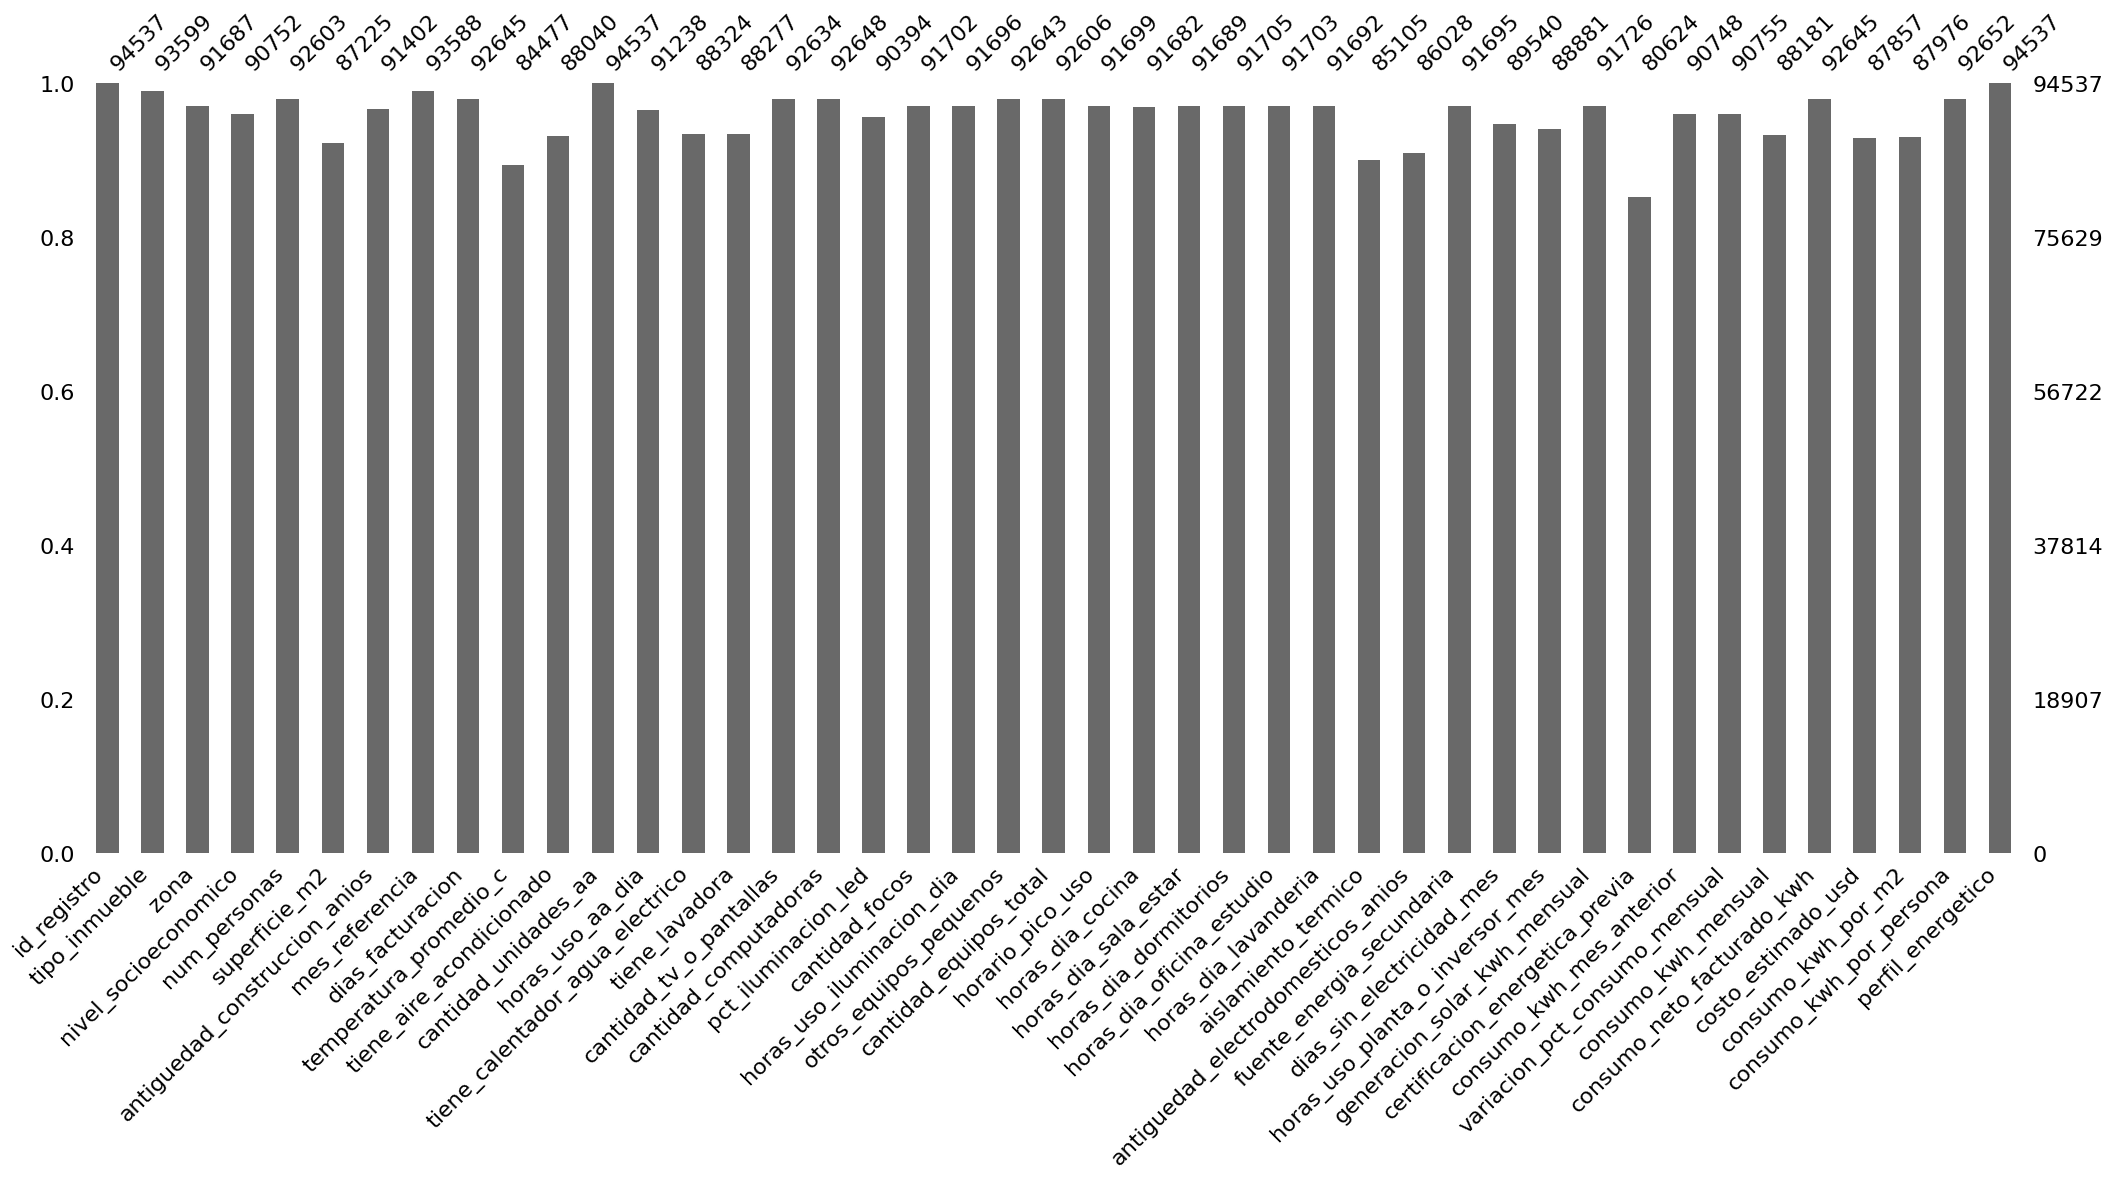

In [ ]:

# 3. Gráfico de barras: Para ver el conteo limpio
msno.bar(bd)
plt.show()

Dentro de la información más importante que se distingue del gráfico de barras de Missingno está que la variable objetivo, `perfil_energetico`, no tiene ningún valor nulo, mientras que, a simple vista, se distinguen variables como `certificacion_energetica_previa` o `temperatura_promedio_c` como aquellas con más valores vacíos. Aunque este gráfico no nos da pistas sobre el comportamiento de los nulos, ofrece una visión general de las variables en las que se podrían enfocar esfuerzos en el futuro.


Visualización: Matriz de Completitud (msno.matrix)



**Análisis:**
- **Densidad:** El gráfico permite identificar visualmente áreas donde los datos faltan de manera concentrada.
- **Patrones:** Si observamos líneas horizontales vacías o bloques de nulos, sugiere que la ausencia de información podría estar correlacionada con subgrupos específicos de inmuebles o condiciones de recolección de datos.

<Axes: >

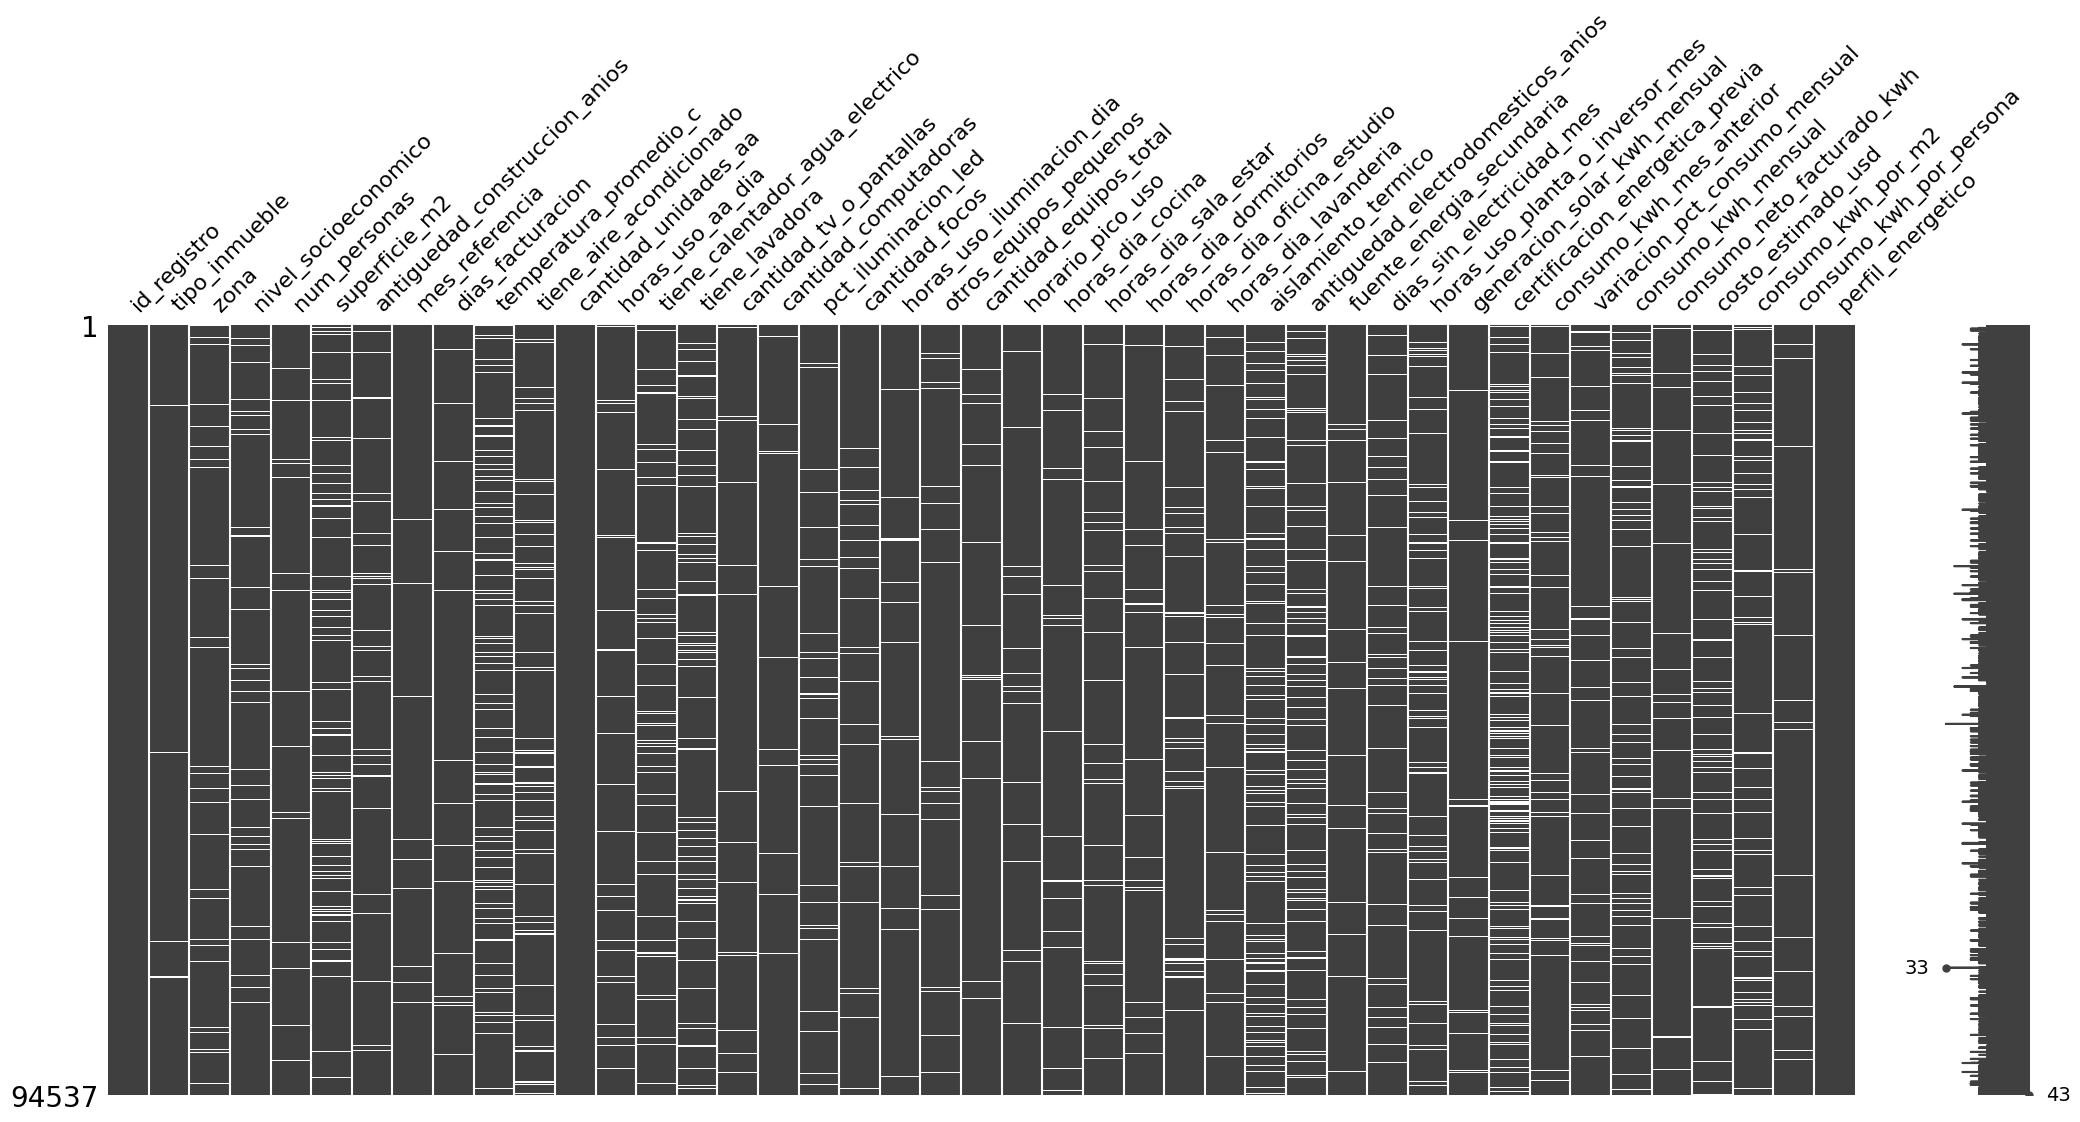

In [ ]:
# 1. Matriz de nulos: Ideal para ver la dispersión global
msno.matrix(bd)

Respecto a la matriz de completitud, se observa una baja presencia de datos faltantes en el conjunto de datos. La distribución de las líneas blancas confirma la información presentada previamente en la tabla de valores nulos, ya que permite identificar visualmente las variables con una mayor proporción de valores ausentes, como `certificacion_energetica_previa`.

Por otro lado, la distribución de los datos no parece revelar algún comportamiento que relacione la presencia de valores nulos entre una o más variables, por lo que, en principio, se muestran indicios de un mecanismo de ausencia completamente aleatorio o MCAR (*Missing Completely At Random*).



Visualización: Dendrograma de Correlación (msno.dendrogram)


**Análisis:**
- **Interpretación:** Las variables que se agrupan (distancia cercana a cero) tienen una correlación fuerte en la ausencia de sus datos.
- **Mecanismo de datos:** Si dos variables se agrupan estrechamente, es un indicador fuerte de que el mecanismo de falta de datos es **MAR (Missing at Random)**, ya que la ausencia de información en una variable está condicionada por la otra. Esto es vital para justificar tu estrategia de imputación.

<Axes: >

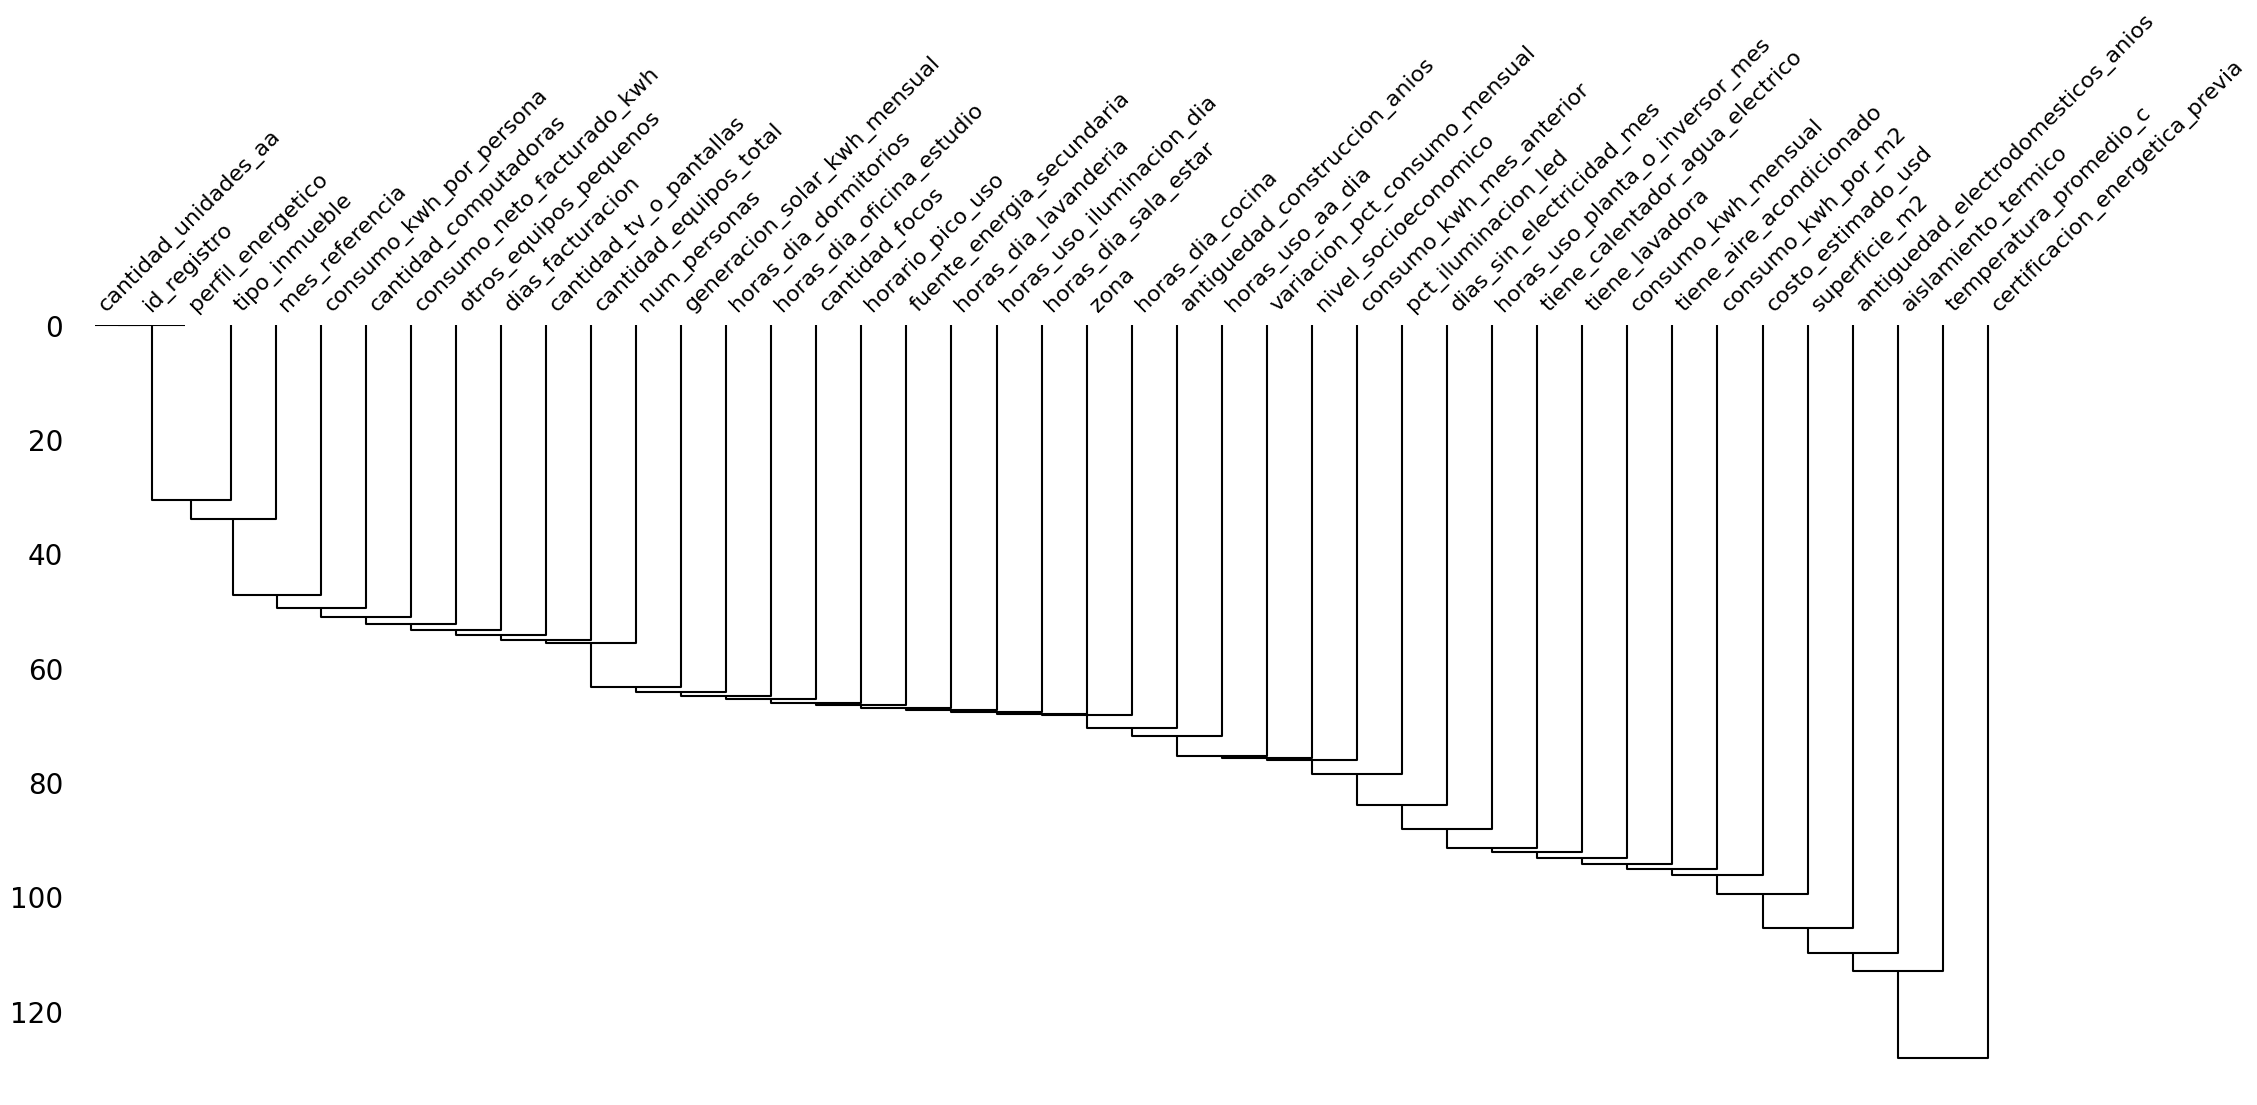

In [ ]:
# 2. Dendrograma: Vital para detectar mecanismos
msno.dendrogram(bd)

l dendrograma revela que las variables cantidad_unidades_aa e id_registro presentan patrones de completitud similares. No obstante, esta asociación tiene poca relevancia para el modelado predictivo, ya que id_registro corresponde a un identificador único y no constituye una variable explicativa. Sin embargo, esta similitud todavía podría ser útil para detectar posibles patrones relacionados con la recopilación o el registro de los datos.

Respecto a las demás variables, las uniones del dendrograma se encuentran aproximadamente entre las alturas 30 y 130. Para la comparación directa entre dos columnas binarias puede utilizarse la fórmula (d=\sqrt{k}), donde (k) representa el número de filas en las que ambas columnas presentan estados de completitud diferentes; es decir, una contiene un valor nulo y la otra un valor no nulo.

De este modo, una distancia de 30 correspondería a:

[
k=30^2=900
]

filas con diferentes estados de completitud, lo que representa aproximadamente un 0,95 % de los 94.537 registros del conjunto de datos.

Sin embargo, una altura de 130 no debe interpretarse necesariamente como:

[
k=130^2=16.900
]

filas diferentes entre dos variables individuales. En las zonas superiores del dendrograma, las alturas suelen representar la distancia entre grupos de variables y no únicamente la distancia directa entre dos columnas. Por esta razón, no es posible convertir todas las alturas del dendrograma en un porcentaje exacto de filas diferentes mediante la fórmula (k=d^2).

Además, si dos variables presentan individualmente entre un 3 % y un 4 % de valores nulos, la proporción de filas en las que sus patrones pueden diferir se encuentra, en teoría, entre el 0 % y aproximadamente el 8 %. El valor mínimo se produciría si los datos nulos aparecieran exactamente en las mismas filas, mientras que el máximo se produciría si aparecieran en filas completamente distintas.

La elevada similitud observada entre algunas variables puede explicarse porque entre el 96 % y el 97 % de sus valores están presentes. En consecuencia, existe una alta probabilidad de que ambas variables coincidan en su estado de dato no nulo. No obstante, para determinar si sus valores faltantes siguen realmente un patrón relacionado, es necesario observar específicamente si los nulos aparecen en las mismas filas y no limitarse a la coincidencia general de valores presentes.

Matriz del número de nulos coincidentes entre variables:



Variable comparada,tipo_inmueble,zona,nivel_socioeconomico,num_personas,superficie_m2,antiguedad_construccion_anios,mes_referencia,dias_facturacion,temperatura_promedio_c,tiene_aire_acondicionado,horas_uso_aa_dia,tiene_calentador_agua_electrico,tiene_lavadora,cantidad_tv_o_pantallas,cantidad_computadoras,pct_iluminacion_led,cantidad_focos,horas_uso_iluminacion_dia,otros_equipos_pequenos,cantidad_equipos_total,horario_pico_uso,horas_dia_cocina,horas_dia_sala_estar,horas_dia_dormitorios,horas_dia_oficina_estudio,horas_dia_lavanderia,aislamiento_termico,antiguedad_electrodomesticos_anios,fuente_energia_secundaria,dias_sin_electricidad_mes,horas_uso_planta_o_inversor_mes,generacion_solar_kwh_mensual,certificacion_energetica_previa,consumo_kwh_mes_anterior,variacion_pct_consumo_mensual,consumo_kwh_mensual,consumo_neto_facturado_kwh,costo_estimado_usd,consumo_kwh_por_m2,consumo_kwh_por_persona
Variable comparada,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
tipo_inmueble,938,33,35,17,68,26,9,19,84,70,37,74,65,22,25,40,30,29,10,16,33,29,33,26,30,31,96,68,35,45,56,23,122,27,36,56,16,65,72,14
zona,33,2850,106,66,233,93,26,42,296,183,106,179,190,57,58,113,73,90,55,65,69,96,115,84,91,85,253,257,83,170,162,84,442,111,130,178,56,190,175,57
nivel_socioeconomico,35,106,3785,82,281,111,37,71,409,266,126,254,268,82,84,175,101,115,88,84,108,121,123,95,132,114,361,311,118,221,223,110,536,138,175,251,74,227,264,62
num_personas,17,66,82,1934,132,58,17,46,217,143,66,139,123,33,41,89,54,64,39,37,62,66,54,71,62,58,195,174,64,92,102,57,260,81,87,118,32,126,128,34
superficie_m2,68,233,281,132,7312,241,81,162,768,509,270,474,471,130,149,340,201,206,153,164,202,196,233,221,223,227,715,679,253,362,431,204,1089,286,290,485,177,526,518,159
antiguedad_construccion_anios,26,93,111,58,241,3135,36,56,360,225,103,206,216,46,56,144,84,102,61,58,107,103,97,74,86,94,321,269,64,160,184,96,485,120,125,212,68,210,209,64
mes_referencia,9,26,37,17,81,36,949,15,116,67,41,47,69,10,14,37,31,29,28,25,26,24,34,33,32,29,85,75,25,47,58,24,156,27,38,57,23,55,67,21
dias_facturacion,19,42,71,46,162,56,15,1892,198,156,57,131,132,37,34,102,65,48,39,55,55,55,51,44,67,56,212,174,53,111,111,48,296,58,79,128,38,138,156,48
temperatura_promedio_c,84,296,409,217,768,360,116,198,10060,674,296,606,643,212,199,436,298,299,210,204,325,300,320,282,314,294,975,961,305,548,564,325,1430,385,428,696,200,714,727,182


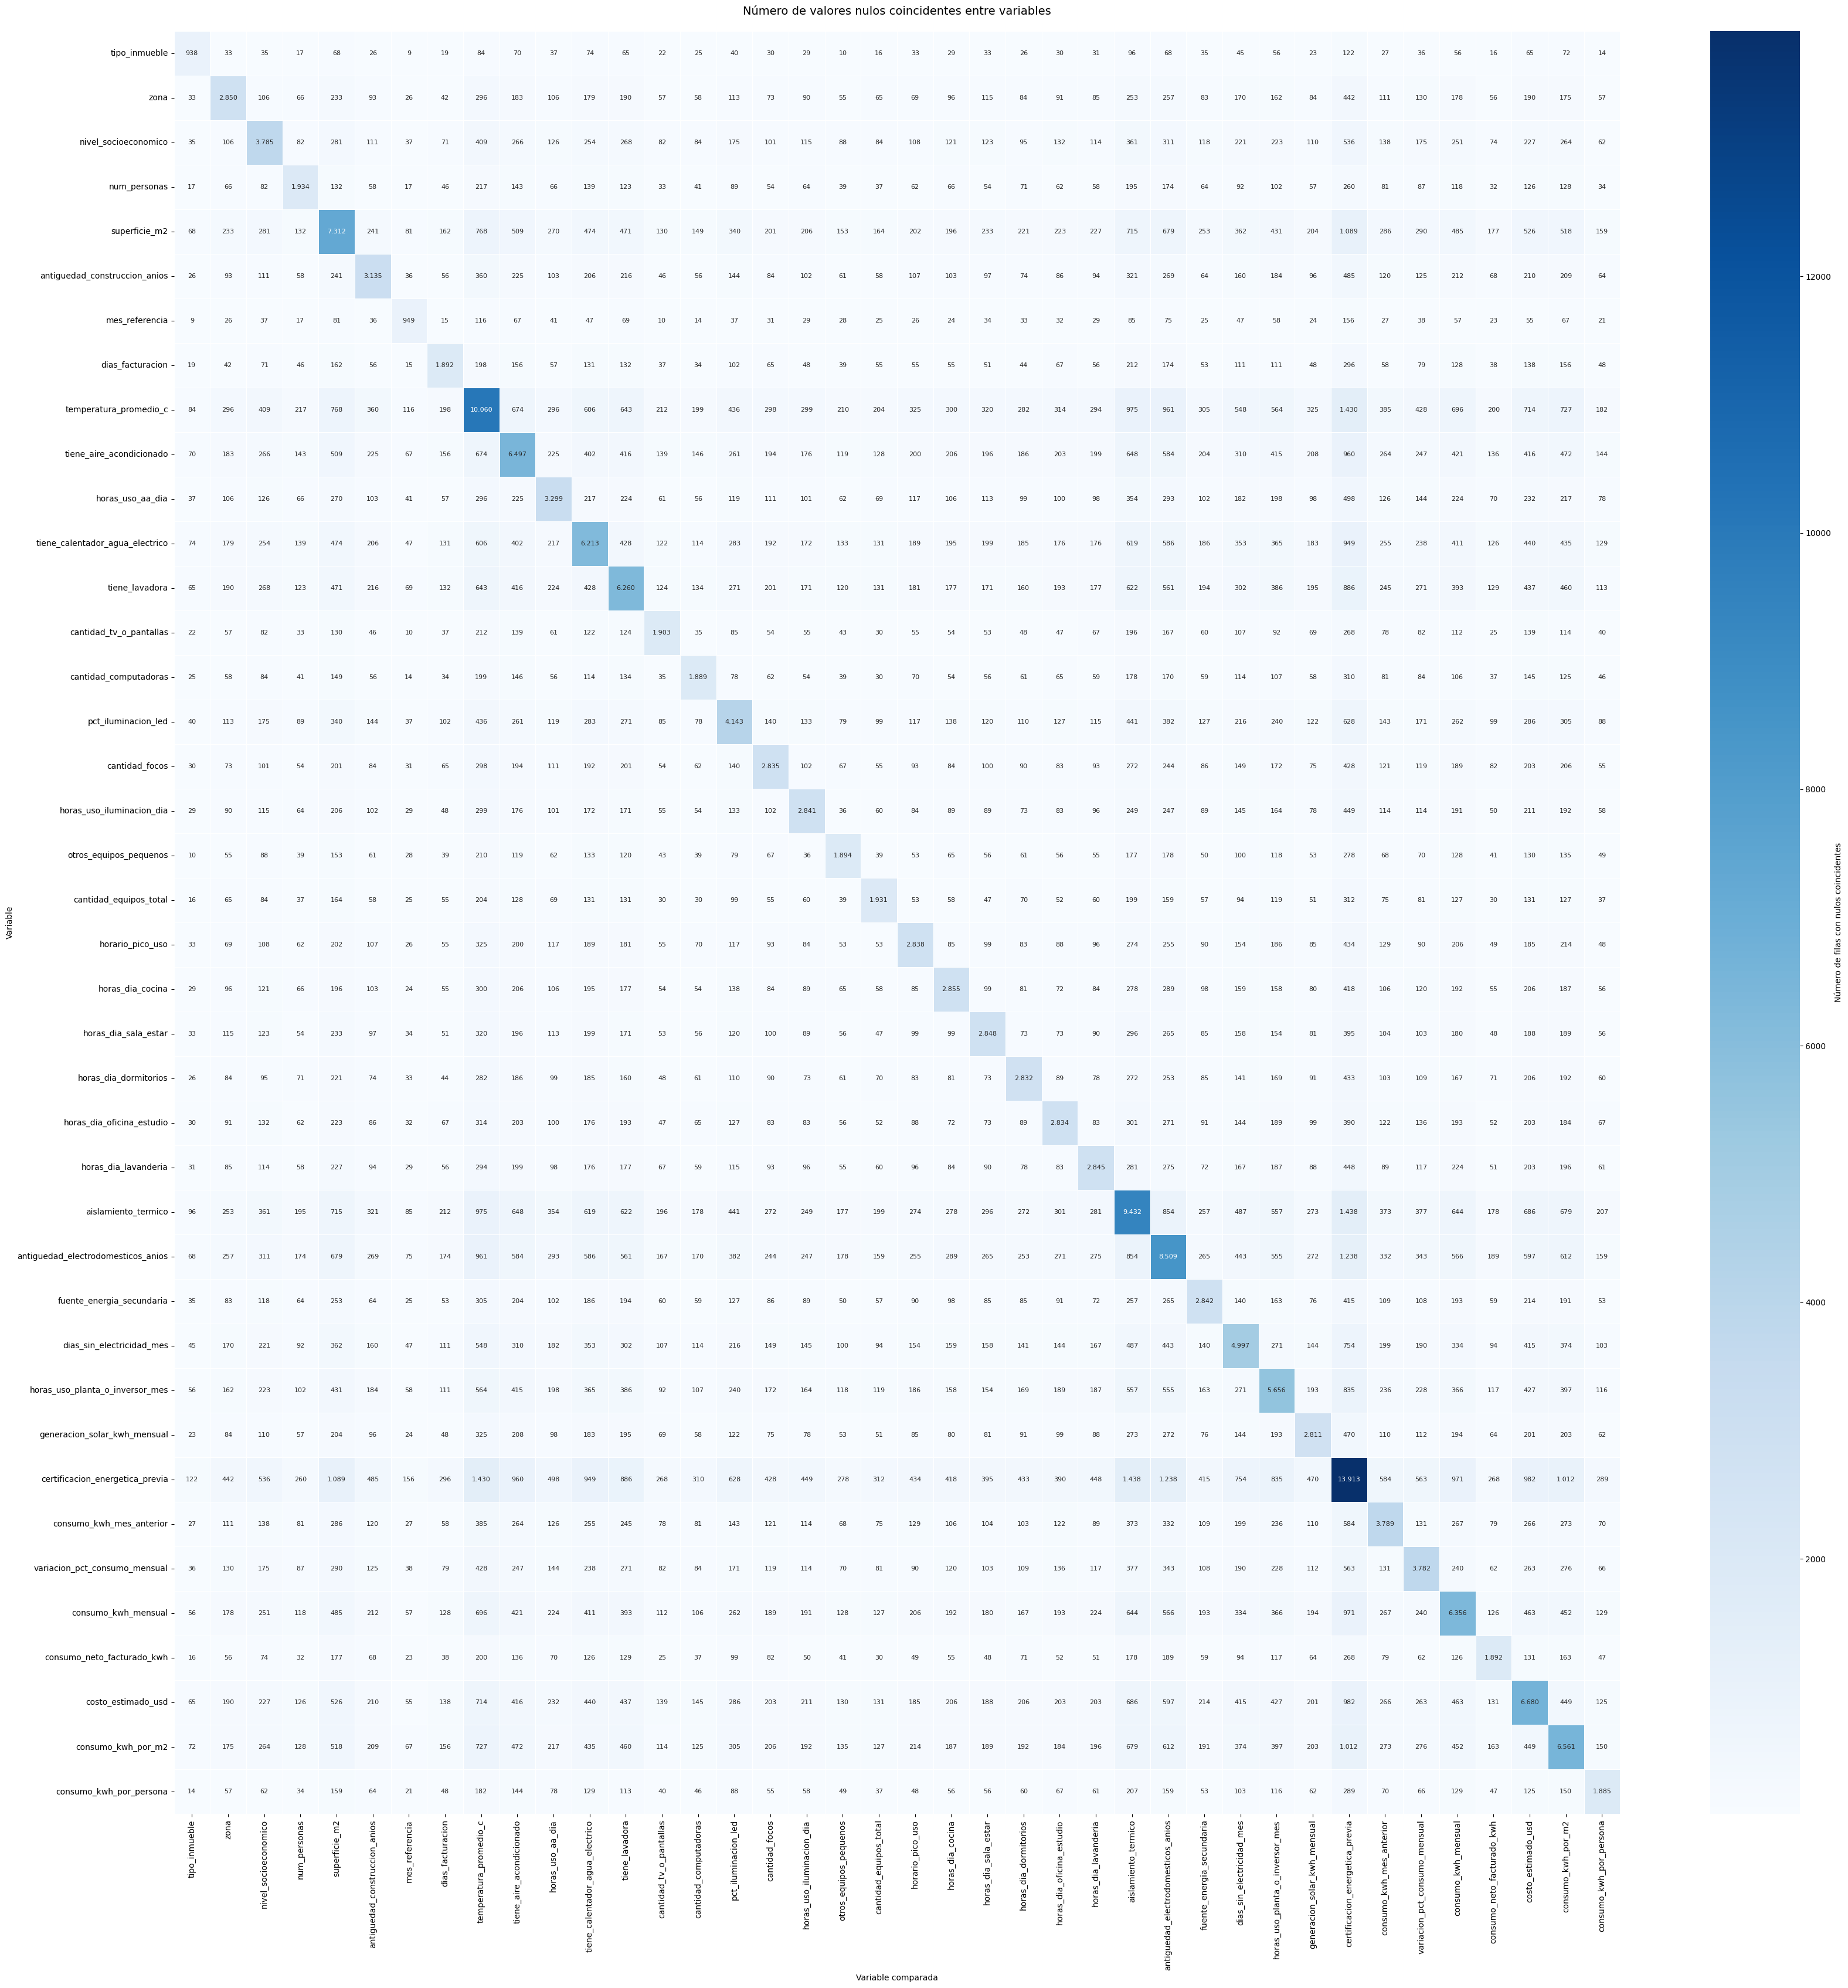

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 1. Crear una matriz binaria de valores nulos
# =========================================================
# 1 = valor nulo
# 0 = valor presente
matriz_binaria_nulos = bd.isna().astype(np.int64)

# Conservar solamente las variables que tienen al menos un nulo
columnas_con_nulos = matriz_binaria_nulos.columns[
    matriz_binaria_nulos.sum(axis=0) > 0
]

matriz_binaria_nulos = matriz_binaria_nulos[columnas_con_nulos]

# =========================================================
# 2. Calcular los nulos coincidentes
# =========================================================
# La multiplicación matricial cuenta las filas en las que
# ambas variables tienen un valor nulo simultáneamente.
matriz_nulos_coincidentes = (
    matriz_binaria_nulos.T @ matriz_binaria_nulos
)

# Convertir los resultados explícitamente a enteros
matriz_nulos_coincidentes = matriz_nulos_coincidentes.astype(int)

# Asignar nombres a los ejes
matriz_nulos_coincidentes.index.name = "Variable"
matriz_nulos_coincidentes.columns.name = "Variable comparada"

# =========================================================
# 3. Mostrar la matriz numérica
# =========================================================
print("Matriz del número de nulos coincidentes entre variables:\n")

display(matriz_nulos_coincidentes)

# =========================================================
# 4. Preparar las etiquetas con separador de miles
# =========================================================
# Ejemplo: 16900 se mostrará como 16.900
etiquetas = matriz_nulos_coincidentes.map(
    lambda valor: f"{valor:,}".replace(",", ".")
)

# =========================================================
# 5. Mostrar la matriz como mapa de calor
# =========================================================
numero_variables = len(matriz_nulos_coincidentes.columns)

if numero_variables > 0:

    # Ajustar automáticamente el tamaño del gráfico
    tamaño = max(10, numero_variables * 0.85)

    plt.figure(figsize=(tamaño, tamaño))

    sns.heatmap(
        matriz_nulos_coincidentes,
        annot=etiquetas,
        fmt="",
        cmap="Blues",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={
            "label": "Número de filas con nulos coincidentes"
        },
        annot_kws={
            "fontsize": 8
        }
    )

    plt.title(
        "Número de valores nulos coincidentes entre variables",
        fontsize=14,
        pad=20
    )

    plt.xlabel("Variable comparada")
    plt.ylabel("Variable")

    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

else:
    print("El conjunto de datos no contiene valores nulos.")

In [ ]:
import pandas as pd
import numpy as np

# =========================================================
# 1. Crear matriz binaria de valores nulos
# =========================================================
# 1 = valor nulo
# 0 = valor no nulo
matriz_binaria_nulos = bd.isna().astype(np.int64)

# Conservar únicamente las variables con al menos un valor nulo
columnas_con_nulos = matriz_binaria_nulos.columns[
    matriz_binaria_nulos.sum(axis=0) > 0
]

matriz_binaria_nulos = matriz_binaria_nulos[columnas_con_nulos]

# =========================================================
# 2. Calcular cantidad de nulos por variable
# =========================================================
cantidad_nulos = matriz_binaria_nulos.sum(axis=0)

# =========================================================
# 3. Calcular nulos coincidentes entre variables
# =========================================================
matriz_nulos_coincidentes = (
    matriz_binaria_nulos.T @ matriz_binaria_nulos
).astype(int)

# =========================================================
# 4. Crear el DataFrame con las variables como columnas
# =========================================================
resultados = {}

for variable in matriz_nulos_coincidentes.columns:

    # Obtener coincidencias de la variable actual
    coincidencias = matriz_nulos_coincidentes[variable].copy()

    # Eliminar la coincidencia de la variable consigo misma
    coincidencias = coincidencias.drop(variable)

    # Seleccionar las cinco variables con más nulos coincidentes
    top_5 = coincidencias.nlargest(5)

    nulos_variable = int(cantidad_nulos[variable])

    datos_variable = {}

    # Guardar los nombres de las cinco variables
    for posicion, variable_coincidente in enumerate(top_5.index, start=1):
        datos_variable[
            f"variable_mayor_coincidencia_{posicion}"
        ] = variable_coincidente

    # Guardar el número total de nulos de la variable principal
    datos_variable["numero_nulos"] = nulos_variable

    # Guardar cantidades de nulos coincidentes
    for posicion, cantidad in enumerate(top_5.values, start=1):
        datos_variable[
            f"nulos_coincidentes_{posicion}"
        ] = int(cantidad)

    # Guardar proporciones respecto a los nulos de la variable principal
    for posicion, cantidad in enumerate(top_5.values, start=1):

        proporcion = (
            cantidad / nulos_variable
            if nulos_variable > 0
            else np.nan
        )

        datos_variable[
            f"proporcion_coincidencia_{posicion}"
        ] = round(proporcion, 4)

    resultados[variable] = datos_variable

# =========================================================
# 5. Convertir los resultados en un DataFrame
# =========================================================
df_coincidencias_formato_matriz = pd.DataFrame(resultados)

print(
    "Variables con mayor coincidencia de nulos, "
    "cantidad de nulos y proporciones:\n"
)

display(df_coincidencias_formato_matriz)

Variables con mayor coincidencia de nulos, cantidad de nulos y proporciones:



,tipo_inmueble,zona,nivel_socioeconomico,num_personas,superficie_m2,antiguedad_construccion_anios,mes_referencia,dias_facturacion,temperatura_promedio_c,tiene_aire_acondicionado,horas_uso_aa_dia,tiene_calentador_agua_electrico,tiene_lavadora,cantidad_tv_o_pantallas,cantidad_computadoras,pct_iluminacion_led,cantidad_focos,horas_uso_iluminacion_dia,otros_equipos_pequenos,cantidad_equipos_total,horario_pico_uso,horas_dia_cocina,horas_dia_sala_estar,horas_dia_dormitorios,horas_dia_oficina_estudio,horas_dia_lavanderia,aislamiento_termico,antiguedad_electrodomesticos_anios,fuente_energia_secundaria,dias_sin_electricidad_mes,horas_uso_planta_o_inversor_mes,generacion_solar_kwh_mensual,certificacion_energetica_previa,consumo_kwh_mes_anterior,variacion_pct_consumo_mensual,consumo_kwh_mensual,consumo_neto_facturado_kwh,costo_estimado_usd,consumo_kwh_por_m2,consumo_kwh_por_persona
variable_mayor_coincidencia_1,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,aislamiento_termico,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa,certificacion_energetica_previa
variable_mayor_coincidencia_2,aislamiento_termico,temperatura_promedio_c,temperatura_promedio_c,temperatura_promedio_c,temperatura_promedio_c,temperatura_promedio_c,temperatura_promedio_c,aislamiento_termico,aislamiento_termico,temperatura_promedio_c,aislamiento_termico,aislamiento_termico,temperatura_promedio_c,temperatura_promedio_c,temperatura_promedio_c,aislamiento_termico,temperatura_promedio_c,temperatura_promedio_c,temperatura_promedio_c,temperatura_promedio_c,temperatura_promedio_c,temperatura_promedio_c,temperatura_promedio_c,temperatura_promedio_c,temperatura_promedio_c,temperatura_promedio_c,temperatura_promedio_c,temperatura_promedio_c,temperatura_promedio_c,temperatura_promedio_c,temperatura_promedio_c,temperatura_promedio_c,temperatura_promedio_c,temperatura_promedio_c,temperatura_promedio_c,temperatura_promedio_c,temperatura_promedio_c,temperatura_promedio_c,temperatura_promedio_c,aislamiento_termico
variable_mayor_coincidencia_3,temperatura_promedio_c,antiguedad_electrodomesticos_anios,aislamiento_termico,aislamiento_termico,aislamiento_termico,aislamiento_termico,aislamiento_termico,temperatura_promedio_c,antiguedad_electrodomesticos_anios,aislamiento_termico,temperatura_promedio_c,temperatura_promedio_c,aislamiento_termico,aislamiento_termico,aislamiento_termico,temperatura_promedio_c,aislamiento_termico,aislamiento_termico,antiguedad_electrodomesticos_anios,aislamiento_termico,aislamiento_termico,antiguedad_electrodomesticos_anios,aislamiento_termico,aislamiento_termico,aislamiento_termico,aislamiento_termico,antiguedad_electrodomesticos_anios,aislamiento_termico,antiguedad_electrodomesticos_anios,aislamiento_termico,aislamiento_termico,aislamiento_termico,antiguedad_electrodomesticos_anios,aislamiento_termico,aislamiento_termico,aislamiento_termico,antiguedad_electrodo

Ninguna de las variables supera el 17 % de coincidencia de valores nulos con otra variable, lo que sugiere que, en la mayoría de los casos, no existe un patrón conjunto claro que explique la ausencia de datos en el conjunto de datos.

Visualización: Mapa de Calor de Correlación de Nulos (msno.heatmap)

**Análisis:**
- **Interpretación:** Este mapa de calor mide la correlación de nulidad entre pares de columnas. El coeficiente varía de -1 a 1, indicando qué tan fuertemente la presencia o ausencia de un valor en una variable afecta a otra.

<Axes: >

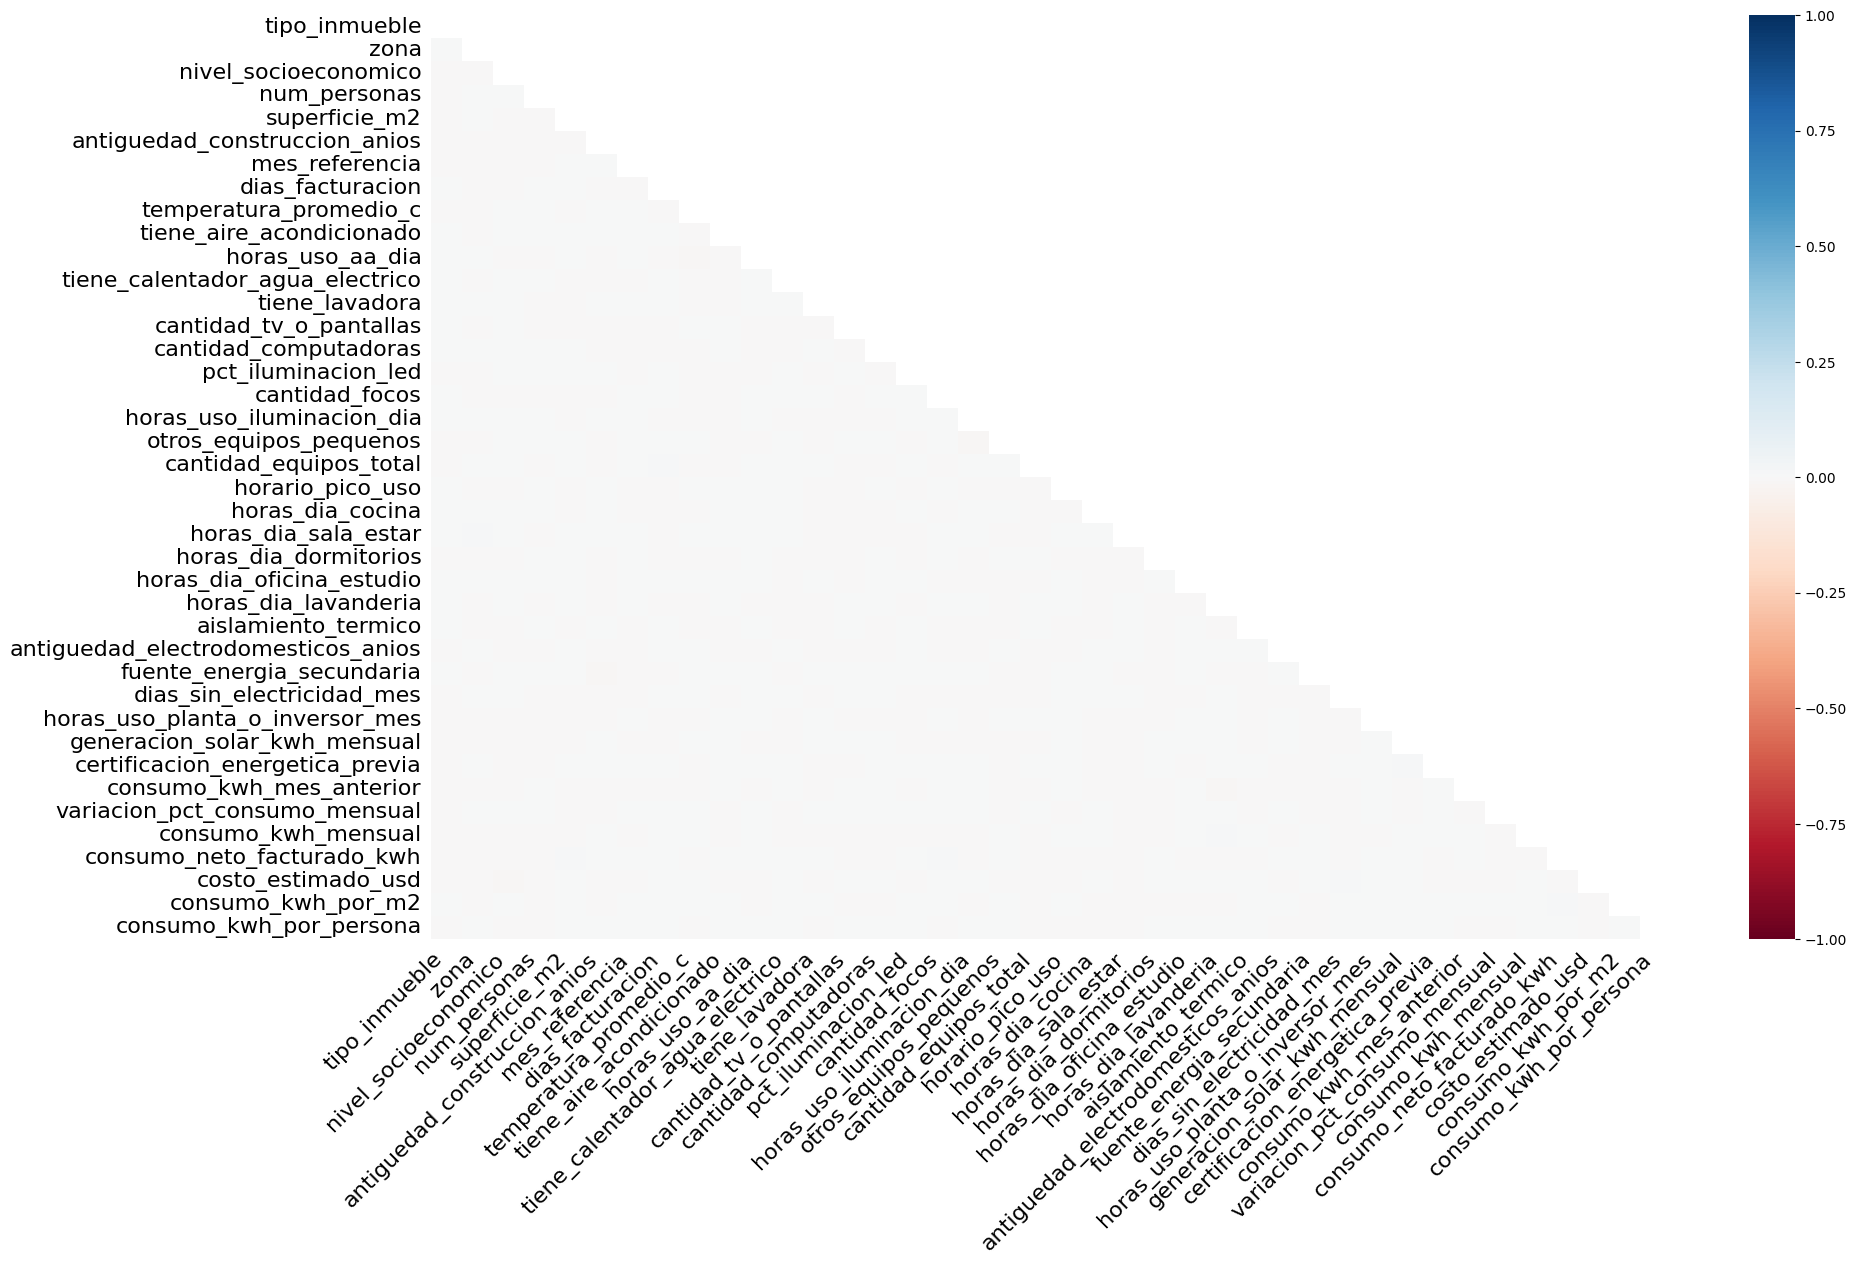

In [ ]:

msno.heatmap(bd)

Al analizar el mapa de calor de correlación de valores nulos, se observa que no existen relaciones significativas entre la ausencia de datos de las distintas variables. La única correlación que destaca corresponde a horas_uso_aa_dia y cantidad_unidades_aa; sin embargo, esta presenta una intensidad moderada, con un coeficiente de aproximadamente 0.5.

Este resultado sugiere que existe una asociación moderada entre la ausencia de datos de ambas variables, es decir, que en una proporción de los casos la ausencia de valores en horas_uso_aa_dia coincide con la ausencia de valores en cantidad_unidades_aa. No obstante, la magnitud de esta correlación no es lo suficientemente alta como para afirmar una dependencia fuerte entre ambas variables, por lo que será necesario realizar análisis adicionales para determinar si dicho patrón responde a un mecanismo específico de ausencia de datos.

In [ ]:
# ==========================================================
# ANÁLISIS DE VALORES FALTANTES
# DataFrame: bd
# ==========================================================

print("="*80)
print("ANÁLISIS DE VALORES FALTANTES")
print("="*80)

# ==========================================================
# TABLA 1
# Nulos por variable
# ==========================================================

print("\n[1] Valores faltantes por variable\n")

total_registros = len(bd)

reporte_nulos = pd.DataFrame({

    "Variable": bd.columns,

    "Cantidad de nulos": [
        int(bd[col].isna().sum())
        for col in bd.columns
    ],

    "Porcentaje (%)": [
        (bd[col].isna().sum() / total_registros) * 100
        for col in bd.columns
    ]

})

reporte_nulos["Porcentaje (%)"] = (
    reporte_nulos["Porcentaje (%)"]
    .round(2)
)

display(

    reporte_nulos.sort_values(
        by="Cantidad de nulos",
        ascending=False
    ).reset_index(drop=True)

)

# ==========================================================
# TABLA 2
# Resumen general del dataset
# ==========================================================

print("\n[2] Resumen general del dataset\n")

total_celdas = bd.shape[0] * bd.shape[1]

total_nulos = int(bd.isna().sum().sum())

porcentaje_nulos = (
    total_nulos / total_celdas
) * 100

resumen = pd.DataFrame({

    "Total de registros": [bd.shape[0]],

    "Total de variables": [bd.shape[1]],

    "Total de celdas": [total_celdas],

    "Cantidad total de nulos": [total_nulos],

    "Porcentaje total de nulos (%)": [
        round(porcentaje_nulos, 2)
    ]

})

display(resumen)

# ==========================================================
# RESUMEN
# ==========================================================

print("\n"+"="*80)
print("RESUMEN")
print("="*80)

print(f"Variables analizadas          : {bd.shape[1]}")
print(f"Registros analizados          : {bd.shape[0]}")
print(f"Valores faltantes totales     : {total_nulos}")
print(f"Porcentaje de nulos del dataset: {porcentaje_nulos:.2f}%")

print("\nProceso finalizado correctamente.")

In [ ]:
# ==========================================================
# CLASIFICACIÓN DE VARIABLES SEGÚN EL DICCIONARIO DE DATOS
# ==========================================================

clasificacion = {
    "id_registro": "Identificador",

    "tipo_inmueble": "Categórica Nominal",
    "zona": "Categórica Nominal",
    "nivel_socioeconomico": "Categórica Ordinal",

    "num_personas": "Numérica Discreta",
    "superficie_m2": "Numérica Continua",
    "antiguedad_construccion_anios": "Numérica Discreta",

    "mes_referencia": "Categórica Ordinal",

    "dias_facturacion": "Numérica Discreta",
    "temperatura_promedio_c": "Numérica Continua",

    "tiene_aire_acondicionado": "Binaria",
    "cantidad_unidades_aa": "Numérica Discreta",
    "horas_uso_aa_dia": "Numérica Continua",

    "tiene_calentador_agua_electrico": "Binaria",
    "tiene_lavadora": "Binaria",

    "cantidad_tv_o_pantallas": "Numérica Discreta",
    "cantidad_computadoras": "Numérica Discreta",

    "pct_iluminacion_led": "Numérica Continua",

    "cantidad_focos": "Numérica Discreta",

    "horas_uso_iluminacion_dia": "Numérica Continua",

    "otros_equipos_pequenos": "Numérica Discreta",
    "cantidad_equipos_total": "Numérica Discreta",

    "horario_pico_uso": "Categórica Ordinal",

    "horas_dia_cocina": "Numérica Continua",
    "horas_dia_sala_estar": "Numérica Continua",
    "horas_dia_dormitorios": "Numérica Continua",
    "horas_dia_oficina_estudio": "Numérica Continua",
    "horas_dia_lavanderia": "Numérica Continua",

    "aislamiento_termico": "Categórica Ordinal",

    "antiguedad_electrodomesticos_anios": "Numérica Continua",

    "fuente_energia_secundaria": "Categórica Nominal",

    "dias_sin_electricidad_mes": "Numérica Discreta",

    "horas_uso_planta_o_inversor_mes": "Numérica Continua",

    "generacion_solar_kwh_mensual": "Numérica Continua",

    "certificacion_energetica_previa": "Binaria",

    "consumo_kwh_mes_anterior": "Numérica Continua",

    "variacion_pct_consumo_mensual": "Numérica Continua",

    "consumo_kwh_mensual": "Numérica Continua",

    "consumo_neto_facturado_kwh": "Numérica Continua",

    "costo_estimado_usd": "Numérica Continua",

    "consumo_kwh_por_m2": "Numérica Continua",

    "consumo_kwh_por_persona": "Numérica Continua",

    "perfil_energetico": "Variable Objetivo (Categórica Ordinal)"
}

df_clasificacion = pd.DataFrame([clasificacion])

display(df_clasificacion)

# FASE 2: CORRECCIONES DETERMINÍSTICAS

## Propósito del bloque

La Fase 2 tiene como propósito corregir inconsistencias lógicas entre variables relacionadas antes de aplicar los métodos estadísticos de imputación. Estas correcciones se fundamentan en relaciones físicas, matemáticas y jerárquicas que pueden determinarse directamente a partir de la información disponible.

El bloque busca evitar que el modelo de imputación reciba combinaciones imposibles o contradictorias, como registrar horas de uso de un equipo que supuestamente no existe, declarar generación solar sin una fuente de energía compatible o presentar un total de dispositivos inferior a la suma de sus componentes.

También permite completar valores faltantes cuando estos pueden deducirse de manera inequívoca, reservando la imputación multivariada para aquellos casos en los que no existe una solución determinística.

## Métodos utilizados

Las correcciones se realizan mediante máscaras booleanas construidas con operaciones lógicas sobre las columnas del DataFrame `bd`.

Los principales métodos utilizados son:

* Validación de la existencia de las columnas mediante `all()` antes de ejecutar cada conjunto de reglas.
* Identificación de valores faltantes mediante `isna()` y `notna()`.
* Evaluación de categorías mediante `isin()`.
* Combinación de condiciones con los operadores lógicos `&`, `|` y `~`.
* Uso de `fillna(False)` para impedir que los valores nulos presentes en las condiciones sean interpretados como coincidencias.
* Selección y modificación de registros mediante `bd.loc[mask, columna]`.
* Sustitución de inconsistencias por `NaN` cuando el valor debe ser estimado posteriormente mediante imputación.
* Asignación de cero cuando la ausencia o inactividad de un equipo se puede determinar de manera directa.
* Cálculo de variables totales mediante la suma de sus componentes.
* Generación de reportes con el nombre de cada regla y la cantidad de registros modificados.

Las reglas se organizan en seis grupos:

1. Cantidad de dispositivos.
2. Aire acondicionado.
3. Iluminación.
4. Lavandería.
5. Respaldo eléctrico y energía solar.
6. Balance eléctrico mensual e inventario.

En total, el código implementa **18 reglas determinísticas**.

## Resultado

Como resultado, el conjunto de datos queda preparado para la fase de imputación, con una mayor coherencia entre las variables relacionadas.

Las principales correcciones realizadas son:

* Reconstrucción del total de equipos a partir de sus componentes.
* Corrección de indicadores de posesión de equipos mediante evidencia de uso.
* Conversión de valores contradictorios a `NaN` para permitir una imputación posterior.
* Asignación de cero en variables que representan equipos o actividades inexistentes.
* Normalización de la fuente de energía secundaria según la generación solar o el uso de sistemas de respaldo.
* Corrección de variables derivadas cuando el consumo eléctrico es igual a cero.
* Ajuste del consumo neto y del costo cuando la generación solar cubre o supera el consumo mensual.

Es importante señalar que la condición:

`consumo_kwh_mes_anterior == 0 y consumo_kwh_mensual > 0`

no se modifica en esta fase. Aunque aparece mencionada en la descripción preliminar del notebook, el código indica explícitamente que este caso se gestiona posteriormente en la Fase 5.

## Reglas determinísticas

### GRP_01: Cantidad de dispositivos

* `cantidad_equipos_total es NaN` y todos los componentes están completos
  → `cantidad_equipos_total = cantidad_tv_o_pantallas + cantidad_computadoras + otros_equipos_pequenos`.

* `cantidad_equipos_total < suma de los componentes`, el total no es nulo y todos los componentes están completos
  → `cantidad_equipos_total = suma de los componentes`.

### GRP_02: Aire acondicionado

* `cantidad_unidades_aa > 0` o `horas_uso_aa_dia > 0`
  → `tiene_aire_acondicionado = 1`.

* (`tiene_aire_acondicionado == 1` o `horas_uso_aa_dia > 0`) y `cantidad_unidades_aa == 0`
  → `cantidad_unidades_aa = NaN` para que posteriormente sea imputada.

* `tiene_aire_acondicionado == 0` y (`cantidad_unidades_aa es NaN` o `horas_uso_aa_dia es NaN`)
  → `cantidad_unidades_aa = 0` y `horas_uso_aa_dia = 0`.

### GRP_03: Iluminación

* `cantidad_focos == 0` y (`pct_iluminacion_led > 0` o `horas_uso_iluminacion_dia > 0`)
  → `cantidad_focos = NaN` para permitir la imputación de una cantidad positiva coherente.

* `cantidad_focos == 0` después de corregir los casos con evidencia positiva
  → `pct_iluminacion_led = 0` y `horas_uso_iluminacion_dia = 0`.

* `horas_uso_iluminacion_dia == 0` y `cantidad_focos es NaN`
  → `cantidad_focos = 0` y `pct_iluminacion_led = 0`.

### GRP_04: Lavandería

* `horas_dia_lavanderia > 0` y `tiene_lavadora != 1`
  → `tiene_lavadora = 1`.

* `tiene_lavadora == 0` y `horas_dia_lavanderia es NaN`
  → `horas_dia_lavanderia = 0`.

* `horas_dia_lavanderia == 0` y `tiene_lavadora es NaN`
  → `tiene_lavadora = 0`.

### GRP_05: Respaldo eléctrico y energía solar

* `generacion_solar_kwh_mensual > 0`, `horas_uso_planta_o_inversor_mes == 0` y la fuente es nula o equivale a “Ninguna”
  → `fuente_energia_secundaria = "Panel Solar"`.

* `horas_uso_planta_o_inversor_mes > 0` y la fuente equivale a “Ninguna”
  → `fuente_energia_secundaria = NaN` para que sea imputada posteriormente.

* `fuente_energia_secundaria` equivale a “Ninguna”
  → `horas_uso_planta_o_inversor_mes = 0` y `generacion_solar_kwh_mensual = 0`.

* `dias_sin_electricidad_mes == 0`, la fuente no es “Panel Solar” ni “Solar” y las horas de uso son nulas
  → `horas_uso_planta_o_inversor_mes = 0`.

### GRP_06: Balance eléctrico mensual e inventario

* `consumo_kwh_mensual == 0`
  → `consumo_kwh_por_m2 = 0`, `consumo_kwh_por_persona = 0`, `costo_estimado_usd = 0` y `consumo_neto_facturado_kwh = 0`.

* `consumo_kwh_mes_anterior == 0` y `consumo_kwh_mensual == 0`
  → `variacion_pct_consumo_mensual = 0`.

* `generacion_solar_kwh_mensual > 0` y `generacion_solar_kwh_mensual >= consumo_kwh_mensual`
  → `consumo_neto_facturado_kwh = 0` y `costo_estimado_usd = 0`.


In [ ]:
print("="*80)
print("CORRECCIONES DETERMINÍSTICAS")
print("="*80)

reporte = []

# ==========================================================
# CORRECCIONES DETERMINÍSTICAS PREVIAS A LA IMPUTACIÓN
# DataFrame: bd | Grupo: GRP_01 (Cantidad de dispositivos)
# ==========================================================

# ==========================================================
# REGLA 1
# Rescate de Total Vacío: Si el total es NaN y los 3 componentes existen -> Suma de partes
# ==========================================================

if all(c in bd.columns for c in [
    "cantidad_tv_o_pantallas",
    "cantidad_computadoras",
    "otros_equipos_pequenos",
    "cantidad_equipos_total"
]):

    cols_comp = ["cantidad_tv_o_pantallas", "cantidad_computadoras", "otros_equipos_pequenos"]

    # Condición estricta: Todas las variables de componentes deben ser diferentes de null
    comp_completos = bd[cols_comp].notna().all(axis=1)

    suma_comp = bd[cols_comp].sum(axis=1)

    # Captura las filas donde el total está vacío PERO tenemos el desglose completo
    mask = (bd["cantidad_equipos_total"].isna() & comp_completos).fillna(False)

    n = int(mask.sum())

    if n > 0:
        bd.loc[mask, "cantidad_equipos_total"] = suma_comp[mask]

    reporte.append({
        "Regla": "Total vacio (NaN) con componentes completos → suma de dispositivos",
        "Correcciones": n
    })

# ==========================================================
# REGLA 2
# Blindaje Físico de Inventario: Si el total < suma de partes (sin nulos) -> Elevar a la suma
# ==========================================================

if all(c in bd.columns for c in [
    "cantidad_tv_o_pantallas",
    "cantidad_computadoras",
    "otros_equipos_pequenos",
    "cantidad_equipos_total"
]):

    cols_comp = ["cantidad_tv_o_pantallas", "cantidad_computadoras", "otros_equipos_pequenos"]

    # Condición estricta: Todas las variables de componentes deben ser diferentes de null
    comp_completos = bd[cols_comp].notna().all(axis=1)

    suma_comp = bd[cols_comp].sum(axis=1)

    # Captura imposibilidades físicas SOLO si el total existe Y no falta ningún componente
    mask = (
        (bd["cantidad_equipos_total"] < suma_comp)
        &
        (bd["cantidad_equipos_total"].notna())
        &
        comp_completos
    ).fillna(False)

    n = int(mask.sum())

    if n > 0:
        bd.loc[mask, "cantidad_equipos_total"] = suma_comp[mask]

    reporte.append({
        "Regla": "Total < Suma dispositivos (sin nulos) → ajustar a la suma",
        "Correcciones": n
    })

# ==========================================================
# REPORTE
# ==========================================================

print("\nResumen de las correcciones\n")

df_reporte = pd.DataFrame(reporte)

display(df_reporte)

print()
print(f"Total de reglas aplicadas : {len(df_reporte)}")
print(f"Total de correcciones     : {df_reporte['Correcciones'].sum()}")
print("\nProceso finalizado correctamente.")

In [ ]:
# ==========================================================
# CORRECCIONES DETERMINÍSTICAS PREVIAS A LA IMPUTACIÓN
# DataFrame: bd | Grupo: GRP_02 (Aire acondicionado)
# ==========================================================

reporte = []

# ==========================================================
# REGLA 1
# Evidencia Positiva: Si hay equipos O hay horas -> tiene AA = 1
# ==========================================================

if all(c in bd.columns for c in [
    "tiene_aire_acondicionado",
    "cantidad_unidades_aa",
    "horas_uso_aa_dia"
]):

    mask = (
        (bd["cantidad_unidades_aa"] > 0)
        |
        (bd["horas_uso_aa_dia"] > 0)
    ).fillna(False)

    n = int(mask.sum())

    if n > 0:
        bd.loc[mask, "tiene_aire_acondicionado"] = 1.0

    reporte.append({
        "Regla": "Evidencia > 0 (Equipos u Horas) → tiene_aa = 1",
        "Correcciones": n
    })

# ==========================================================
# REGLA 2
# Corrección de Inventario: Si tiene AA = 1 O Horas > 0, con Equipos == 0 -> Equipos = NaN
# ==========================================================

if all(c in bd.columns for c in [
    "tiene_aire_acondicionado",
    "cantidad_unidades_aa",
    "horas_uso_aa_dia"
]):

    mask = (
        (
            (bd["tiene_aire_acondicionado"] == 1)
            |
            (bd["horas_uso_aa_dia"] > 0)
        )
        &
        (bd["cantidad_unidades_aa"] == 0)
    ).fillna(False)

    n = int(mask.sum())

    if n > 0:
        bd.loc[mask, "cantidad_unidades_aa"] = np.nan

    reporte.append({
        "Regla": "Tiene AA=1 o Horas>0 con Equipos=0 → equipos = NaN",
        "Correcciones": n
    })

# ==========================================================
# REGLA 3 (CIERRE DE NEGACIÓN EXPLÍCITA)
# Si declaró NO tener AA (booleano == 0) -> Equipos = 0 y Horas = 0
# ==========================================================

if all(c in bd.columns for c in [
    "tiene_aire_acondicionado",
    "cantidad_unidades_aa",
    "horas_uso_aa_dia"
]):

    mask = (
        (bd["tiene_aire_acondicionado"] == 0)
        &
        (bd["cantidad_unidades_aa"].isna() | bd["horas_uso_aa_dia"].isna())
    ).fillna(False)

    n = int(mask.sum())

    if n > 0:
        bd.loc[mask, "cantidad_unidades_aa"] = 0.0
        bd.loc[mask, "horas_uso_aa_dia"] = 0.0

    reporte.append({
        "Regla": "Sin AA (booleano=0) → equipos = 0, horas = 0",
        "Correcciones": n
    })

# ==========================================================
# REPORTE
# ==========================================================

print("\nResumen de las correcciones\n")

df_reporte = pd.DataFrame(reporte)

display(df_reporte)

print()
print(f"Total de reglas aplicadas : {len(df_reporte)}")
print(f"Total de correcciones     : {df_reporte['Correcciones'].sum()}")
print("\nProceso finalizado correctamente.")

In [ ]:
# ==========================================================
# CORRECCIONES DETERMINÍSTICAS PREVIAS A LA IMPUTACIÓN
# DataFrame: bd | Grupo: GRP_03 (Iluminación)
# ==========================================================

print("="*80)
print("CORRECCIONES DETERMINÍSTICAS - ILUMINACIÓN")
print("="*80)

reporte = []

# ==========================================================
# REGLA 1 (Antes Regla 2)
# Evidencia Positiva de Focos: Si hay % LED u horas -> focos > 0
# ==========================================================
# Si el encuestador registró 100% LED o 5 horas de uso, pero anotó 0 focos
# o lo dejó en NaN, se corrige el 0 a NaN para que MICE impute un número
# positivo coherente sin perder la varianza del consumo.

if all(c in bd.columns for c in [
    "cantidad_focos",
    "pct_iluminacion_led",
    "horas_uso_iluminacion_dia"
]):

    mask = (
        (bd["cantidad_focos"] == 0)
        &
        (
            (bd["pct_iluminacion_led"] > 0)
            |
            (bd["horas_uso_iluminacion_dia"] > 0)
        )
    ).fillna(False)

    n = int(mask.sum())

    if n > 0:
        # Se asigna NaN en lugar de 1.0 para que la imputación multivariada
        # estime la cantidad real según los m2 y el consumo eléctrico del hogar.
        bd.loc[mask, "cantidad_focos"] = np.nan

    reporte.append({
        "Regla": "Evidencia > 0 (% LED u Horas) con Focos == 0 → Focos a NaN",
        "Correcciones": n
    })

# ==========================================================
# REGLA 2 (Antes Regla 1)
# Jerarquía de Inventario: Si cantidad_focos == 0 -> todo a 0
# ==========================================================
# El inventario físico manda. Si la casa tiene genuinamente 0 focos, es
# matemáticamente imposible que tenga un porcentaje LED o registre horas de uso.

if all(c in bd.columns for c in [
    "cantidad_focos",
    "pct_iluminacion_led",
    "horas_uso_iluminacion_dia"
]):

    mask = (bd["cantidad_focos"] == 0).fillna(False)

    n = int(mask.sum())

    if n > 0:
        bd.loc[mask, "pct_iluminacion_led"] = 0.0
        bd.loc[mask, "horas_uso_iluminacion_dia"] = 0.0

    reporte.append({
        "Regla": "Focos == 0 → pct_led = 0, horas = 0",
        "Correcciones": n
    })

# ==========================================================
# REGLA 3
# Cierre de Negación de Horas: Si horas == 0 -> foco apagado
# ==========================================================
# Si no hay uso registrado (horas == 0) pero las otras variables quedaron
# vacías (NaN), no podemos asumir que no hay focos, pero sí podemos confirmar
# que no están generando consumo eléctrico ni aportando a la tecnología LED activa.

if all(c in bd.columns for c in [
    "cantidad_focos",
    "pct_iluminacion_led",
    "horas_uso_iluminacion_dia"
]):

    mask = (
        (bd["horas_uso_iluminacion_dia"] == 0)
        &
        (bd["cantidad_focos"].isna())
    ).fillna(False)

    n = int(mask.sum())

    if n > 0:
        bd.loc[mask, "cantidad_focos"] = 0.0
        bd.loc[mask, "pct_iluminacion_led"] = 0.0

    reporte.append({
        "Regla": "Horas == 0 y Focos NaN → Focos = 0, pct_led = 0",
        "Correcciones": n
    })

# ==========================================================
# REPORTE
# ==========================================================

print("\nResumen de las correcciones\n")

df_reporte = pd.DataFrame(reporte)

display(df_reporte)

print()
print(f"Total de reglas aplicadas : {len(df_reporte)}")
print(f"Total de correcciones     : {df_reporte['Correcciones'].sum()}")
print("\nProceso finalizado correctamente.")

In [ ]:
# ==========================================================
# CORRECCIONES DETERMINÍSTICAS PREVIAS A LA IMPUTACIÓN
# DataFrame: bd | Grupo: GRP_04 (Lavandería)
# ==========================================================

print("="*80)
print("CORRECCIONES DETERMINÍSTICAS - LAVANDERÍA")
print("="*80)

reporte = []

# ==========================================================
# REGLA 1
# Evidencia Positiva de Uso: Si horas > 0 -> tiene_lavadora = 1
# ==========================================================
# La conducta de uso es la evidencia más fuerte. Si el hogar registró
# horas activas de lavado pero el booleano está en 0 (error de tipeo)
# o en NaN (en blanco), se confirma la propiedad del electrodoméstico.

if all(c in bd.columns for c in [
    "tiene_lavadora",
    "horas_dia_lavanderia"
]):

    mask = (
        (bd["horas_dia_lavanderia"] > 0)
        &
        (bd["tiene_lavadora"] != 1)  # Atrapa tanto 0.0 como NaN
    ).fillna(False)

    n = int(mask.sum())

    if n > 0:
        bd.loc[mask, "tiene_lavadora"] = 1.0

    reporte.append({
        "Regla": "Evidencia > 0 (Horas Lavandería) → tiene_lavadora = 1",
        "Correcciones": n
    })

# ==========================================================
# REGLA 2
# Equivalencia / Negación: Si tiene_lavadora == 0 -> horas = 0
# ==========================================================
# Si el encuestador declaró explícitamente que NO hay lavadora en el hogar,
# y la celda de horas quedó vacía (NaN), se normaliza a 0.0 para evitar
# que MICE intente imputarle horas de lavado a una casa sin equipo.
# (Ejecutada después de la Regla 1, no borra horas reales de uso).

if all(c in bd.columns for c in [
    "tiene_lavadora",
    "horas_dia_lavanderia"
]):

    mask = (
        (bd["tiene_lavadora"] == 0)
        &
        (bd["horas_dia_lavanderia"].isna())
    ).fillna(False)

    n = int(mask.sum())

    if n > 0:
        bd.loc[mask, "horas_dia_lavanderia"] = 0.0

    reporte.append({
        "Regla": "Sin lavadora (booleano == 0) → horas = 0",
        "Correcciones": n
    })

# ==========================================================
# REGLA 3
# Cierre de Inactividad: Si horas == 0 y booleano NaN -> tiene_lavadora = 0
# ==========================================================
# Si un hogar registró 0.0 horas de lavado y dejó la pregunta de propiedad
# en blanco (NaN), se asume determinísticamente como 0.0 para evitar crear
# electrodomésticos fantasma durante la imputación estadística.

if all(c in bd.columns for c in [
    "tiene_lavadora",
    "horas_dia_lavanderia"
]):

    mask = (
        (bd["horas_dia_lavanderia"] == 0)
        &
        (bd["tiene_lavadora"].isna())
    ).fillna(False)

    n = int(mask.sum())

    if n > 0:
        bd.loc[mask, "tiene_lavadora"] = 0.0

    reporte.append({
        "Regla": "Horas == 0 con booleano NaN → tiene_lavadora = 0",
        "Correcciones": n
    })

# ==========================================================
# REPORTE
# ==========================================================

print("\nResumen de las correcciones\n")

df_reporte = pd.DataFrame(reporte)

display(df_reporte)

print()
print(f"Total de reglas aplicadas : {len(df_reporte)}")
print(f"Total de correcciones     : {df_reporte['Correcciones'].sum()}")
print("\nProceso finalizado correctamente.")

In [ ]:
# ==========================================================
# CORRECCIONES DETERMINÍSTICAS PREVIAS A LA IMPUTACIÓN
# DataFrame: bd | Grupo: GRP_05 (Respaldo y Energía Solar)
# ==========================================================

print("="*80)
print("CORRECCIONES DETERMINÍSTICAS - RESPALDO Y ENERGÍA SOLAR")
print("="*80)

reporte = []

cols_grp04 = [
    "dias_sin_electricidad_mes",
    "fuente_energia_secundaria",
    "horas_uso_planta_o_inversor_mes",
    "generacion_solar_kwh_mensual"
]

if all(c in bd.columns for c in cols_grp04):

    # ==========================================================
    # REGLA 1 (PROTECCIÓN DE SISTEMAS HÍBRIDOS + ESTÁNDAR 'Panel Solar')
    # Evidencia Positiva Solar: Si hay generación > 0 y horas == 0 -> fuente = 'Panel Solar'
    # ==========================================================
    mask_solar = (
        (bd["generacion_solar_kwh_mensual"] > 0)
        &
        (bd["horas_uso_planta_o_inversor_mes"] == 0)
        &
        (
            bd["fuente_energia_secundaria"].isin(["Ninguna", "ninguna", "0", 0])
            |
            bd["fuente_energia_secundaria"].isna()
        )
    ).fillna(False)

    n1 = int(mask_solar.sum())
    if n1 > 0:
        bd.loc[mask_solar, "fuente_energia_secundaria"] = "Panel Solar"

    reporte.append({
        "Regla": "Generación solar > 0, horas == 0 en vacíos/'Ninguna' → fuente = 'Panel Solar'",
        "Correcciones": n1
    })

    # ==========================================================
    # REGLA 2
    # Evidencia de Respaldo: Si hay horas de planta con fuente 'Ninguna' -> fuente a NaN
    # ==========================================================
    mask_evidencia_planta = (
        (bd["horas_uso_planta_o_inversor_mes"] > 0)
        &
        (bd["fuente_energia_secundaria"].isin(["Ninguna", "ninguna", "0", 0]))
    ).fillna(False)

    n2 = int(mask_evidencia_planta.sum())
    if n2 > 0:
        bd.loc[mask_evidencia_planta, "fuente_energia_secundaria"] = np.nan

    reporte.append({
        "Regla": "Horas planta > 0 con fuente 'Ninguna' → fuente a NaN",
        "Correcciones": n2
    })

    # ==========================================================
    # REGLA 3
    # Jerarquía de Fuente: Si fuente == 'Ninguna' -> horas = 0 y generación = 0
    # ==========================================================
    mask_ninguna = (
        bd["fuente_energia_secundaria"].isin(["Ninguna", "ninguna", "0", 0])
    ).fillna(False)

    n3 = int(mask_ninguna.sum())
    if n3 > 0:
        bd.loc[mask_ninguna, "horas_uso_planta_o_inversor_mes"] = 0.0
        bd.loc[mask_ninguna, "generacion_solar_kwh_mensual"] = 0.0

    reporte.append({
        "Regla": "Fuente == 'Ninguna' → horas_planta = 0, generacion_solar = 0",
        "Correcciones": n3
    })

    # ==========================================================
    # REGLA 4
    # Sin Cortes Eléctricos: Si días corte == 0 y no es Panel Solar -> horas planta = 0
    # ==========================================================
    mask_sin_cortes = (
        (bd["dias_sin_electricidad_mes"] == 0)
        &
        (~bd["fuente_energia_secundaria"].isin(["Panel Solar", "Solar"]))
        &
        (bd["horas_uso_planta_o_inversor_mes"].isna())
    ).fillna(False)

    n4 = int(mask_sin_cortes.sum())
    if n4 > 0:
        bd.loc[mask_sin_cortes, "horas_uso_planta_o_inversor_mes"] = 0.0

    reporte.append({
        "Regla": "Sin cortes (días=0) y no Panel Solar con horas NaN → horas_planta = 0",
        "Correcciones": n4
    })

# ==========================================================
# REPORTE
# ==========================================================

print("\nResumen de las correcciones\n")
df_reporte = pd.DataFrame(reporte)
display(df_reporte)

print()
print(f"Total de reglas aplicadas : {len(df_reporte)}")
print(f"Total de correcciones     : {df_reporte['Correcciones'].sum() if not df_reporte.empty else 0}")
print("\nProceso finalizado correctamente.")

In [ ]:
# ==========================================================
# CORRECCIONES DETERMINÍSTICAS PREVIAS A LA IMPUTACIÓN
# DataFrame: bd | Grupo: GRP_06 (Balance Eléctrico Mensual e Inventario)
# ==========================================================

print("="*80)
print("FASE 1: CORRECCIONES PREVIAS (PRE-IMPUTACIÓN MICE)")
print("="*80)

reporte_pre = []

cols_base = [
    "consumo_kwh_mensual",
    "consumo_kwh_mes_anterior",
    "superficie_m2",
    "num_personas",
    "generacion_solar_kwh_mensual",
    "cantidad_tv_o_pantallas",
    "cantidad_computadoras",
    "otros_equipos_pequenos"
]

cols_derivadas = [
    "consumo_kwh_por_m2",
    "consumo_kwh_por_persona",
    "costo_estimado_usd",
    "variacion_pct_consumo_mensual",
    "consumo_neto_facturado_kwh",
    "cantidad_equipos_total"
]

if all(c in bd.columns for c in cols_base + cols_derivadas):

    # ==========================================================
    # REGLA 1
    # Consumo Nulo: Si consumo_kwh_mensual == 0 -> derivadas a 0
    # ==========================================================
    mask_cero_consumo = (bd["consumo_kwh_mensual"] == 0).fillna(False)

    n1 = int(mask_cero_consumo.sum())
    if n1 > 0:
        bd.loc[mask_cero_consumo, "consumo_kwh_por_m2"] = 0.0
        bd.loc[mask_cero_consumo, "consumo_kwh_por_persona"] = 0.0
        bd.loc[mask_cero_consumo, "costo_estimado_usd"] = 0.0
        bd.loc[mask_cero_consumo, "consumo_neto_facturado_kwh"] = 0.0

    reporte_pre.append({
        "Regla": "Consumo mensual == 0 → ratios por m2, persona, costo y neto = 0",
        "Correcciones": n1
    })

    # ==========================================================
    # REGLA 2
    # Variación Controlada: Si ambos consumos son 0 -> variación = 0.0
    # (Se excluye el caso mes anterior == 0 y mensual > 0, ya que se gestiona en Fase 5)
    # ==========================================================
    mask_ambos_cero = (
        (bd["consumo_kwh_mes_anterior"] == 0) &
        (bd["consumo_kwh_mensual"] == 0)
    ).fillna(False)

    n2 = int(mask_ambos_cero.sum())
    if n2 > 0:
        bd.loc[mask_ambos_cero, "variacion_pct_consumo_mensual"] = 0.0

    reporte_pre.append({
        "Regla": "Consumo anterior == 0 y mensual == 0 → variación porcentual = 0.0",
        "Correcciones": n2
    })

    # ==========================================================
    # REGLA 3
    # Coherencia de Consumo Neto y Solar
    # ==========================================================
    gen_solar = bd["generacion_solar_kwh_mensual"].fillna(0)
    mask_solar_excede = ((gen_solar > 0) & (gen_solar >= bd["consumo_kwh_mensual"])).fillna(False)

    n3 = int(mask_solar_excede.sum())
    if n3 > 0:
        bd.loc[mask_solar_excede, ["consumo_neto_facturado_kwh", "costo_estimado_usd"]] = 0.0

    reporte_pre.append({
        "Regla": "Generación solar >= consumo → neto y costo = 0",
        "Correcciones": n3
    })

print("\nResumen de correcciones previas a la imputación:\n")
df_reporte_pre = pd.DataFrame(reporte_pre)
display(df_reporte_pre)
print(f"Total de correcciones previas : {df_reporte_pre['Correcciones'].sum() if not df_reporte_pre.empty else 0}")

# FASE 3: CODIFICACIÓN TEMPORAL DE VARIABLES CATEGÓRICAS

## Propósito del bloque

La Fase 3 tiene como propósito transformar temporalmente las variables categóricas del conjunto de datos en representaciones numéricas que puedan ser procesadas por el método de imputación multivariada utilizado en la fase siguiente.

Esta transformación es necesaria porque el `IterativeImputer` de Scikit-learn trabaja con matrices numéricas y no puede procesar directamente variables almacenadas como texto. Por esta razón, las categorías originales se sustituyen por códigos numéricos mediante `OrdinalEncoder`.

Durante el proceso se preservan los valores faltantes como `NaN`, de modo que puedan ser identificados e imputados posteriormente por el modelo MICE. Además, se construye un diccionario de trazabilidad que conserva la relación entre cada categoría original y el código numérico asignado.

La codificación se considera temporal porque, una vez terminada la imputación, los códigos numéricos deberán convertirse nuevamente a sus categorías originales.

## Métodos utilizados

La codificación temporal se desarrolla mediante los siguientes procedimientos:

### 1. Definición de las variables categóricas

Se crea una lista con las variables categóricas que deben convertirse a formato numérico:

* `tipo_inmueble`
* `zona`
* `nivel_socioeconomico`
* `mes_referencia`
* `horario_pico_uso`
* `aislamiento_termico`
* `fuente_energia_secundaria`

La variable `certificacion_energetica_previa` no se incluye porque ya se encuentra representada numéricamente como una variable binaria de tipo `float64`. Y `perfil_energetico` porque es la variable dependiente.

### 2. Verificación de la existencia de las columnas

Antes de ejecutar la codificación, se comprueba cuáles variables de la lista se encuentran realmente dentro del DataFrame `bd`.

Para ello se utiliza una comprensión de lista que conserva únicamente las columnas existentes:

```python
cols_presentes = [
    c for c in cols_fase3_ordinal
    if c in bd.columns
]
```

Esta validación evita que el proceso genere un error cuando alguna de las columnas esperadas no está disponible en el conjunto de datos.

### 3. Configuración del codificador ordinal

La transformación se realiza mediante `OrdinalEncoder`, configurado con los siguientes parámetros:

```python
encoder_ordinal = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=np.nan,
    encoded_missing_value=np.nan
)
```

Los parámetros cumplen las siguientes funciones:

* `handle_unknown="use_encoded_value"`: permite controlar categorías nuevas o desconocidas.
* `unknown_value=np.nan`: convierte las categorías desconocidas en valores faltantes.
* `encoded_missing_value=np.nan`: conserva los valores originalmente ausentes como `NaN`.

Esta configuración evita que los valores faltantes sean reemplazados por códigos artificiales, como `-1`, que podrían ser interpretados incorrectamente por el modelo de imputación.

### 4. Ajuste y transformación de las variables

El codificador aprende las categorías disponibles en cada variable y transforma sus valores mediante:

```python
bd[cols_presentes] = encoder_ordinal.fit_transform(
    bd[cols_presentes]
)
```

El método `fit_transform()` ejecuta dos operaciones:

1. Identifica las categorías presentes en cada columna.
2. Asigna a cada categoría un código numérico.

La transformación se realiza directamente sobre las columnas del DataFrame `bd`.

### 5. Construcción del diccionario de trazabilidad

Después de codificar las variables, se crea el diccionario `diccionario_mapeo`.

Este diccionario almacena, para cada variable, la relación entre la categoría original y el número asignado por `OrdinalEncoder`.

La estructura general del diccionario es:

```python
diccionario_mapeo = {
    "variable": {
        "categoria_original": codigo_numerico
    }
}
```

Durante su construcción se excluyen valores NaN.

De esta manera, el diccionario contiene únicamente categorías válidas y puede utilizarse posteriormente para revertir la codificación.

### 6. Control de valores faltantes

Finalmente, se calcula la cantidad de valores nulos que permanece en cada variable codificada:

```python
nulos_por_columna = bd[cols_presentes].isna().sum()
```

El reporte muestra únicamente las variables cuya cantidad de valores faltantes es superior a cero:

```python
nulos_por_columna[nulos_por_columna > 0]
```

Este control permite confirmar que los valores faltantes fueron preservados y permanecen disponibles para ser tratados por el `IterativeImputer` en la fase siguiente.

## Resultado

Como resultado de la Fase 3, las variables categóricas presentes en el DataFrame quedan convertidas a valores numéricos de tipo decimal, compatibles con los métodos de imputación multivariada de Scikit-learn.

Los principales resultados del bloque son:

* Conversión de hasta siete variables categóricas a códigos numéricos.
* Conservación de los valores faltantes como `NaN`.
* Conversión de categorías desconocidas en `NaN`.
* Exclusión de variables que ya se encuentran en formato numérico o binario.
* Creación de un diccionario con la correspondencia entre categorías y códigos.
* Generación de un reporte de valores faltantes después de la codificación.
* Preparación del DataFrame para la imputación mediante `IterativeImputer`.

Esta fase no completa valores faltantes ni modifica inconsistencias lógicas. Su función es exclusivamente preparar la estructura numérica necesaria para ejecutar la imputación en la Fase 4.

El notebook no conserva las salidas de ejecución de esta celda, dado que la celda aparece sin número de ejecución y con la lista de resultados vacía. Por esta razón, no es posible determinar directamente desde el archivo cuántas variables fueron codificadas realmente, cuáles fueron sus códigos exactos ni cuántos valores nulos permanecieron en cada una.

## Condiciones lógicas y reglas de transformación utilizadas

En esta fase no se utilizan máscaras booleanas para seleccionar registros mediante `bd.loc`, como ocurre en la Fase 2.

Las condiciones se utilizan principalmente para:

* Seleccionar columnas existentes.
* Controlar categorías desconocidas.
* Preservar valores faltantes.
* Filtrar las categorías incluidas en el diccionario.
* Mostrar únicamente las variables que conservan valores nulos.

Las condiciones y transformaciones pueden expresarse de la siguiente manera:

### Selección de columnas

* `columna incluida en cols_fase3_ordinal` y `columna existe en bd.columns`
  → agregar la columna a `cols_presentes`.

* `columna incluida en cols_fase3_ordinal` y `columna no existe en bd.columns`
  → excluir la columna del proceso de codificación.

### Codificación de categorías válidas

* `valor corresponde a una categoría conocida y no es nulo`
  → convertir la categoría al código numérico aprendido por `OrdinalEncoder`.

* `categoría original válida`
  → guardar la relación `categoría → código numérico` en `diccionario_mapeo`.

La asignación puede representarse de forma general como:

```text
categoría original → código numérico ordinal
```

Por ejemplo:

```text
Categoría A → 0.0
Categoría B → 1.0
Categoría C → 2.0
```

Los códigos concretos dependen de las categorías identificadas por el codificador durante su ajuste.

### Tratamiento de valores faltantes

* `valor original es NaN`
  → conservar el valor como `NaN` después de la codificación.

### Tratamiento de categorías desconocidas

* `categoría no fue observada durante el ajuste del OrdinalEncoder`
  → transformar la categoría en `NaN`.

Esta regla es especialmente relevante si el codificador se utiliza posteriormente para transformar nuevos registros que contengan categorías no observadas en el conjunto utilizado para ajustarlo.

### Construcción del diccionario

* `not pd.isna(cat)` y `str(cat).lower() != "nan"`
  → incluir la categoría y su código en `mapeo_columna`.

* `pd.isna(cat)` o `str(cat).lower() == "nan"`
  → excluir la categoría del diccionario de trazabilidad.

### Reporte de valores faltantes

* `cantidad de nulos de la variable > 0`
  → mostrar la variable y su cantidad de valores faltantes en el reporte.

* `cantidad de nulos de la variable == 0`
  → omitir la variable del reporte de nulos.

### Variables excluidas o condicionadas

* `certificacion_energetica_previa ya está codificada como variable binaria numérica`
  → no aplicar `OrdinalEncoder`.

* `perfil_energetico es la variable objetivo del modelo predictivo final`
  →  para evitar posibles problemas metodológicos.


In [ ]:
# ==========================================================
# FASE 3: CODIFICACIÓN TEMPORAL (ORDINAL ENCODING)
# DataFrame: bd | Objetivo: Convertir texto a números preservando NaNs para MICE
# ==========================================================

print("="*80)
print("FASE 2: CODIFICACIÓN ORDINAL PARA IMPUTACIÓN MICE")
print("="*80)

# 1. Lista oficial actualizada (excluyendo variables binarias o ya numéricas)
cols_fase3_ordinal = [
    'tipo_inmueble',
    'zona',
    'nivel_socioeconomico',
    'mes_referencia',
    'horario_pico_uso',
    'aislamiento_termico',
    'fuente_energia_secundaria',
]

# Verificamos qué columnas están presentes en el DataFrame
cols_presentes = [c for c in cols_fase3_ordinal if c in bd.columns]

print(f"Variables a codificar ({len(cols_presentes)}): {cols_presentes}")
print("Variable excluida por formato binario float64 : ['certificacion_energetica_previa']\n")

# 2. Configuración del OrdinalEncoder
# Declarar explícitamente encoded_missing_value=np.nan previene que versiones
# antiguas de sklearn intenten asignarle enteros (como -1) a los NaNs.
encoder_ordinal = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=np.nan,
    encoded_missing_value=np.nan
)

# 3. Ajuste y transformación en el DataFrame
bd[cols_presentes] = encoder_ordinal.fit_transform(bd[cols_presentes])

# 4. Construcción del diccionario de trazabilidad (Mapeo Categoría -> Número)
diccionario_mapeo = {}

print("--- MAPEO DE CATEGORÍAS A NÚMEROS ENTEROS ---")
for col, categorias in zip(cols_presentes, encoder_ordinal.categories_):

    # MODIFICACIÓN CLAVE:
    # Filtramos al vuelo cualquier elemento que sea NaN, 'nan' (texto) o None.
    # Así generamos el diccionario SOLO con las categorías válidas de tu negocio.
    mapeo_columna = {
        str(cat): float(idx)
        for idx, cat in enumerate(categorias)
        if not pd.isna(cat) and str(cat).lower() != 'nan'
    }

    diccionario_mapeo[col] = mapeo_columna

    print(f"\n[{col}]:")
    for texto, num in mapeo_columna.items():
        print(f"  {num} -> {texto}")

# 5. Reporte de control de nulos antes de pasar a Fase 3
print("\n" + "="*80)
print("CONTROL DE NULOS PARA ALIMENTAR MICE (FASE 3)")
print("="*80)
nulos_por_columna = bd[cols_presentes].isna().sum()
print(nulos_por_columna[nulos_por_columna > 0].to_string())
print("\n✔️ Las variables están numéricamente codificadas y listas para el IterativeImputer.")

# FASE 4: IMPUTACIÓN MULTIVARIADA DE VARIABLES NULAS

## Propósito del bloque

La Fase 4 tiene como propósito estimar y completar los valores faltantes presentes en las variables categóricas codificadas y en las variables numéricas del conjunto de datos.

Para realizar esta operación se utiliza `IterativeImputer`, un método de imputación multivariada que estima cada variable incompleta a partir del resto de las variables seleccionadas. Como estimador interno se emplea `RandomForestRegressor`, lo que permite modelar relaciones no lineales y posibles interacciones entre las características del hogar, los equipos, los patrones de uso y el consumo energético.

La fase también incorpora límites mínimos y máximos para evitar que el proceso genere valores físicamente imposibles, como:

* Horas diarias superiores a 24.
* Horas mensuales superiores a 744.
* Porcentajes superiores al 100 %.
* Valores negativos.
* Variables binarias superiores a 1.

El notebook establece que la imputación se aplica tanto sobre variables numéricas como sobre variables categóricas previamente codificadas en la Fase 3.

## Métodos utilizados

### 1. Definición inicial de rangos válidos

Al comienzo de la fase se crea el diccionario `rangos_validos_fase4`, que contiene límites mínimos y máximos específicos para 36 variables.

Los rangos se agrupan según el significado de las variables.

#### Variables categóricas codificadas y binarias

* `tipo_inmueble`: entre `0.0` y `2.0`.
* `zona`: entre `0.0` y `2.0`.
* `nivel_socioeconomico`: entre `0.0` y `2.0`.
* `mes_referencia`: entre `0.0` y `11.0`.
* `horario_pico_uso`: entre `0.0` y `3.0`.
* `aislamiento_termico`: entre `0.0` y `2.0`.
* `fuente_energia_secundaria`: entre `0.0` y `3.0`.
* `certificacion_energetica_previa`: entre `0.0` y `1.0`.

#### Estructura y entorno del hogar

* `num_personas`: entre `1` y `100`.
* `superficie_m2`: entre `10.0` y `10000.0`.
* `antiguedad_construccion_anios`: entre `0` y `150`.
* `temperatura_promedio_c`: entre `15.0` y `45.0`.
* `dias_facturacion`: entre `15` y `45`.

#### Equipos e inventario

* `tiene_aire_acondicionado`: entre `0.0` y `1.0`.
* `cantidad_unidades_aa`: entre `0` y `50`.
* `horas_uso_aa_dia`: entre `0.0` y `24.0`.
* `tiene_calentador_agua_electrico`: entre `0.0` y `1.0`.
* `tiene_lavadora`: entre `0.0` y `1.0`.
* `cantidad_tv_o_pantallas`: entre `0` y `50`.
* `cantidad_computadoras`: entre `0` y `50`.
* `otros_equipos_pequenos`: entre `0` y `200`.
* `cantidad_equipos_total`: entre `0` y `1000`.
* `antiguedad_electrodomesticos_anios`: entre `0.0` y `50.0`.

#### Iluminación y patrones de uso

* `pct_iluminacion_led`: entre `0.0` y `100.0`.
* `cantidad_focos`: entre `0` y `500`.
* Variables de horas diarias: entre `0.0` y `24.0`.

Esto incluye:

* `horas_uso_iluminacion_dia`
* `horas_dia_cocina`
* `horas_dia_sala_estar`
* `horas_dia_dormitorios`
* `horas_dia_oficina_estudio`
* `horas_dia_lavanderia`

#### Respaldo, generación y consumo

* `dias_sin_electricidad_mes`: entre `0` y `31`.
* `horas_uso_planta_o_inversor_mes`: entre `0.0` y `744.0`.
* `generacion_solar_kwh_mensual`: entre `0.0` y `20000.0`.
* `consumo_kwh_mes_anterior`: entre `0.0` y `50000.0`.
* `consumo_kwh_mensual`: entre `0.0` y `50000.0`.

Después se seleccionan las columnas presentes en el DataFrame y se construyen las listas `lista_minimos` y `lista_maximos` con los rangos correspondientes.

### 2. Selección de variables para MICE

Posteriormente se define la lista `cols_fase4_mice`, que contiene las variables que realmente se entregan al imputador.

Aunque el comentario del código señala que contiene 36 variables, la lista posee realmente **35 variables**. VERIFICAR.

Las variables se organizan en cinco grupos:

1. Categorías codificadas y variables binarias.
2. Estructura y entorno del hogar.
3. Equipos e inventario.
4. Iluminación y patrones de uso.
5. Respaldo eléctrico, generación solar y consumos base.

Las variables derivadas, como razones, índices, costos y consumos normalizados, no se incluyen en la imputación. Estas deberán ser recalculadas posteriormente a partir de las variables base.

La variable `cantidad_equipos_total`, aunque aparece en el diccionario inicial de rangos, no se encuentra dentro de `cols_fase4_mice`. Por tanto, no participa en la matriz que finalmente se entrega al `IterativeImputer`.

### 3. Configuración dinámica de límites físicos

Después de crear el diccionario de rangos específicos, el código vuelve a definir los límites mediante dos diccionarios:

```python
limites_min = {col: 0.0 for col in cols_fase4_mice}
limites_max = {col: np.inf for col in cols_fase4_mice}
```

Inicialmente, todas las variables reciben:

* Límite mínimo: `0.0`.
* Límite máximo: infinito.

Posteriormente, el límite máximo se modifica según el nombre y el tipo de cada variable:

* Horas diarias: máximo de `24.0`.
* Horas mensuales: máximo de `744.0`.
* Porcentajes: máximo de `100.0`.
* Variables cuyo nombre comienza con `tiene_`: máximo de `1.0`.

Las demás variables mantienen un máximo infinito.

### 4. Conversión de los límites a listas ordenadas

Los diccionarios dinámicos se convierten nuevamente en listas:

```python
lista_minimos = [
    limites_min[col]
    for col in cols_fase4_mice
]

lista_maximos = [
    limites_max[col]
    for col in cols_fase4_mice
]
```

El orden de estas listas coincide exactamente con el orden de `cols_fase4_mice`, requisito necesario para que cada límite sea aplicado a la variable correspondiente.

Esta segunda construcción reemplaza las listas creadas previamente a partir de `rangos_validos_fase4`. Por esta razón, los límites específicos del primer diccionario no son los que finalmente recibe el imputador.

Por ejemplo:

* `num_personas` termina con mínimo `0.0`, no con mínimo `1`.
* `superficie_m2` termina con mínimo `0.0` y máximo infinito, no entre `10` y `10000`.
* `temperatura_promedio_c` termina entre `0.0` e infinito, no entre `15` y `45`.
* `dias_facturacion` termina entre `0.0` e infinito, no entre `15` y `45`.
* Las variables categóricas codificadas conservan un máximo infinito, salvo las que comienzan con `tiene_`.

El notebook incluye como comentario la posibilidad de establecer límites máximos para las variables categóricas ordinales, pero esas instrucciones están comentadas y no se ejecutan.

### 5. Auditoría de límites

Se crea el DataFrame `df_auditoria_limites`, que contiene:

* Nombre de la variable.
* Límite mínimo.
* Límite máximo.

Además, el código imprime:

* Una muestra de las variables con límite máximo acotado.
* La cantidad de variables con techo definido.
* La cantidad de variables cuyo límite máximo permanece en infinito.

Esta auditoría permite verificar que las listas de límites se encuentren correctamente alineadas con las columnas antes de ejecutar la imputación.

### 6. Configuración de Random Forest

El estimador utilizado dentro de `IterativeImputer` es `RandomForestRegressor`, configurado con los siguientes parámetros:

```python
RandomForestRegressor(
    n_estimators=30,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features=0.7,
    bootstrap=True,
    max_samples=0.70,
    n_jobs=-1,
    random_state=105
)
```

#### `n_estimators=30`

Se construyen 30 árboles de decisión para cada modelo de imputación.

Este valor busca reducir el costo computacional, dado que el bosque debe ajustarse repetidamente durante las iteraciones de MICE.

#### `max_depth=12`

Limita la profundidad máxima de cada árbol a 12 niveles.

Esta restricción evita que los árboles aprendan excesivamente las particularidades del conjunto de datos y ayuda a controlar el sobreajuste.

#### `min_samples_split=10`

Un nodo necesita al menos 10 observaciones para poder dividirse.

Esto evita divisiones sustentadas en una cantidad demasiado pequeña de registros.

#### `min_samples_leaf=5`

Cada hoja debe contener al menos cinco observaciones.

La condición genera predicciones más estables y reduce la creación de hojas excesivamente específicas.

#### `max_features=0.7`

Cada árbol puede evaluar el 70 % de las variables disponibles al buscar la mejor división.

Esto introduce diversidad entre los árboles y reduce la dependencia de un conjunto pequeño de predictores.

#### `bootstrap=True`

Cada árbol se entrena utilizando una muestra con reemplazo de los registros disponibles.

#### `max_samples=0.70`

Cada árbol utiliza el 70 % de las observaciones para construir su muestra bootstrap.

Esta configuración reduce el costo computacional y aumenta la diversidad entre los árboles.

#### `n_jobs=-1`

Se utilizan todos los núcleos de procesamiento disponibles para entrenar el bosque.

#### `random_state=105`

Se fija una semilla para que los resultados puedan reproducirse al volver a ejecutar el notebook.

### 7. Configuración de IterativeImputer

El imputador se configura con los siguientes parámetros:

#### `max_iter=5`

El procedimiento puede realizar hasta cinco rondas completas de imputación.

En cada ronda, las variables con valores faltantes son estimadas nuevamente utilizando los valores disponibles y las estimaciones generadas para las demás variables.

#### `tol=1e-2`

Se utiliza una tolerancia de `0.01` como criterio de convergencia.

El procedimiento puede detenerse antes de completar las cinco iteraciones cuando los cambios entre rondas son suficientemente pequeños.

#### `n_nearest_features=15`

Para imputar cada variable se utilizan hasta 15 variables relacionadas, en lugar de emplear necesariamente todas las columnas disponibles.

Esta configuración reduce el costo computacional y limita la cantidad de predictores incorporados en cada modelo.

#### `initial_strategy="median"`

Antes de iniciar las iteraciones, los valores faltantes reciben una imputación provisional basada en la mediana de cada variable.

Esta asignación inicial permite construir la primera matriz numérica completa necesaria para entrenar los modelos.

#### `imputation_order="ascending"`

Las variables se imputan comenzando por aquellas que poseen menos valores faltantes.

La intención es utilizar primero las columnas con mayor cantidad de información observada.

#### `sample_posterior=False`

No se realiza muestreo posterior.

El proceso genera una estimación puntual para cada valor faltante, lo cual es compatible con el uso de `RandomForestRegressor`.

#### `min_value=lista_minimos`

Se aplican los límites mínimos definidos para cada variable.

#### `max_value=lista_maximos`

Se aplican los límites máximos definidos para cada variable.

#### `random_state=105`

Se mantiene una semilla fija para favorecer la reproducibilidad.

#### `verbose=2`

El imputador muestra información del progreso y de las iteraciones durante su ejecución.

### 8. Ejecución de la imputación

La imputación se ejecuta mediante:

```python
bd[cols_fase4_mice] = imputer_mice.fit_transform(
    bd[cols_fase4_mice]
)
```

El procedimiento realiza las siguientes acciones:

1. Extrae las 36 variables seleccionadas.
2. Realiza una imputación inicial mediante la mediana.
3. Entrena un bosque aleatorio para cada variable con valores faltantes.
4. Predice los valores ausentes utilizando las demás variables seleccionadas.
5. Repite el proceso hasta alcanzar la convergencia o completar cinco iteraciones.
6. Aplica los límites mínimos y máximos.
7. Reemplaza las columnas originales por la matriz imputada.

La transformación devuelve valores numéricos continuos. Por esta razón, las variables categóricas, binarias y de conteo deben redondearse y restaurarse posteriormente en la Fase 5.

## Resultado

Como resultado de la Fase 4, se obtiene una matriz numérica en la que los valores faltantes de las variables seleccionadas son estimados mediante imputación multivariada.

Los principales resultados esperados son:

* Imputación de las variables categóricas previamente codificadas.
* Imputación de variables binarias.
* Imputación de cantidades y conteos.
* Imputación de horas de uso.
* Imputación de características estructurales del hogar.
* Imputación de generación solar y consumos eléctricos.
* Conservación de valores no negativos.
* Restricción de horas, porcentajes y algunas variables binarias.
* Sustitución de las columnas originales por sus versiones imputadas.

Las variables derivadas no se imputan directamente. Estas se reservan para ser recalculadas en la fase posterior utilizando las variables base ya completadas.

El archivo no conserva las salidas de ejecución de las celdas correspondientes a esta fase. En consecuencia, no es posible verificar directamente:

* Cuántos valores fueron imputados.
* Cuántas iteraciones fueron necesarias.
* Si se alcanzó la convergencia antes de la quinta iteración.
* Si quedaron valores nulos después del procedimiento.
* Cuánto tiempo tardó la ejecución.
* Cuál fue la distribución final de los valores imputados.

Por tanto, el código define el procedimiento de imputación, pero el notebook analizado no permite confirmar sus resultados empíricos.

## Reglas determinísticas y condiciones lógicas utilizadas

En esta fase no se utilizan principalmente máscaras booleanas por fila, como ocurre en la Fase 2.

Las condiciones lógicas se aplican sobre los nombres de las columnas para construir los límites del imputador. Por tanto, pueden denominarse **reglas determinísticas de restricción** o **condiciones lógicas de configuración**.

### Regla general de valores no negativos

* `columna incluida en cols_fase4_mice`
  → asignar límite mínimo igual a `0.0`.

* `columna incluida en cols_fase4_mice`
  → asignar inicialmente límite máximo igual a infinito.

### Regla A: Horas diarias

* `"horas_" está contenido en el nombre de la columna` y `"_dia" está contenido en el nombre`
  → asignar límite máximo igual a `24.0`.

Representación:

```text
"horas_" in col and "_dia" in col
→ limites_max[col] = 24.0
```

Esta condición se aplica a variables como:

* `horas_uso_aa_dia`
* `horas_uso_iluminacion_dia`
* `horas_dia_cocina`
* `horas_dia_sala_estar`
* `horas_dia_dormitorios`
* `horas_dia_oficina_estudio`
* `horas_dia_lavanderia`

### Regla B: Horas mensuales

* `"horas_" está contenido en el nombre de la columna` y `"_mes" está contenido en el nombre`
  → asignar límite máximo igual a `744.0`.

Representación:

```text
"horas_" in col and "_mes" in col
→ limites_max[col] = 744.0
```

Esta regla se aplica a:

* `horas_uso_planta_o_inversor_mes`

El límite de 744 corresponde al número máximo de horas de un mes de 31 días.

### Regla C: Porcentajes

* `el nombre de la columna comienza con "pct_"` o `"porcentaje" está contenido en el nombre`
  → asignar límite máximo igual a `100.0`.

Representación:

```text
col.startswith("pct_") or "porcentaje" in col
→ limites_max[col] = 100.0
```

Esta condición se aplica a:

* `pct_iluminacion_led`

### Regla D: Variables binarias identificadas por nombre

* `el nombre de la columna comienza con "tiene_"`
  → asignar límite máximo igual a `1.0`.

Representación:

```text
col.startswith("tiene_")
→ limites_max[col] = 1.0
```

Esta condición se aplica a:

* `tiene_aire_acondicionado`
* `tiene_calentador_agua_electrico`
* `tiene_lavadora`

### Regla para variables sin condición específica

* `la columna no corresponde a horas diarias, horas mensuales, porcentajes ni comienza con "tiene_"`
  → mantener límite máximo igual a infinito.

Esto permite que las variables restantes sean estimadas sin un techo superior específico.

### Regla de alineación de límites

* `columna se encuentra en cols_fase4_mice`
  → agregar su límite mínimo y máximo en la misma posición de `lista_minimos` y `lista_maximos`.

Esta regla garantiza que cada posición de las listas corresponda a la misma posición de la matriz entregada al imputador.

### Regla de imputación

* `valor de una variable incluida en cols_fase4_mice es NaN`
  → estimar el valor mediante `IterativeImputer` utilizando `RandomForestRegressor` y las variables predictoras seleccionadas.

* `valor de una variable no es NaN`
  → conservar el valor observado durante la asignación de la matriz transformada.

### Regla de restricción posterior a la estimación

* `predicción calculada por MICE es menor que min_value de la variable`
  → restringir la estimación al límite mínimo permitido.

* `predicción calculada por MICE es mayor que max_value de la variable`
  → restringir la estimación al límite máximo permitido.

### Reglas ordinales opcionales no ejecutadas

El código incluye como comentarios las siguientes instrucciones:

```python
limites_max["tipo_inmueble"] = 2.0
limites_max["fuente_energia_secundaria"] = 3.0
```

Como están comentadas, no forman parte del procedimiento ejecutado.

Por tanto:

* `tipo_inmueble`
  → conserva máximo infinito durante la imputación.

* `fuente_energia_secundaria`
  → conserva máximo infinito durante la imputación.

Lo mismo sucede con otras categorías codificadas, como `mes_referencia`, `zona`, `nivel_socioeconomico`, `aislamiento_termico` y `perfil_energetico`.

Estas variables pueden recibir temporalmente valores decimales o valores superiores al código máximo de sus categorías. Su restauración dependerá de las operaciones de redondeo y control realizadas en la Fase 5.

## Observaciones sobre la implementación

### 1. Los rangos específicos son reemplazados

El diccionario `rangos_validos_fase4` contiene límites detallados y adecuados para cada variable. Sin embargo, las listas construidas con estos rangos son reemplazadas posteriormente por las listas generadas mediante las reglas dinámicas.

Por esta razón, el imputador utiliza realmente los límites dinámicos generales y no los rangos específicos declarados inicialmente.

### 2. Existe una diferencia en la cantidad de variables

El comentario indica que `cols_fase4_mice` contiene 37 variables, pero la lista contiene 36.

La diferencia se debe a que `cantidad_equipos_total` aparece en `rangos_validos_fase4`, pero no se incluye en `cols_fase4_mice`.

### 3. Las variables categóricas no están limitadas por su número de clases

Las reglas opcionales para restringir las categorías se encuentran comentadas. En consecuencia, `IterativeImputer` puede producir códigos continuos fuera del rango original de las categorías.

Estos valores deberán corregirse mediante redondeo, recorte y decodificación en la Fase 5.

### 4. La variable objetivo participa en la imputación

`perfil_energetico` se incluye dentro de la matriz de imputación.

Esto permite imputar sus valores faltantes utilizando las demás variables. Sin embargo, si posteriormente se utiliza como variable objetivo de un modelo predictivo, debe controlarse cuidadosamente su participación para evitar que la preparación de los datos introduzca información no disponible en un escenario real de predicción.

### 5. Las variables de conteo permanecen continuas temporalmente

El bosque aleatorio utilizado es un regresor. Por tanto, puede generar valores decimales para variables como:

* `num_personas`
* `cantidad_unidades_aa`
* `cantidad_focos`
* `cantidad_tv_o_pantallas`
* `cantidad_computadoras`
* `dias_facturacion`

Estos resultados no representan necesariamente errores de la imputación, ya que el redondeo y la restauración de los tipos se realizan posteriormente en la Fase 5.


In [ ]:
rangos_validos_fase4 = {
    # 1. Categorías codificadas y binarias base
    "tipo_inmueble": (0.0, 2.0),
    "zona": (0.0, 2.0),
    "nivel_socioeconomico": (0.0, 2.0),
    "mes_referencia": (0.0, 11.0),
    "horario_pico_uso": (0.0, 3.0),
    "aislamiento_termico": (0.0, 2.0),
    "fuente_energia_secundaria": (0.0, 3.0),
    "certificacion_energetica_previa": (0.0, 1.0),
    "perfil_energetico": (0.0, 2.0),

    # 2. Estructura y entorno del hogar
    "num_personas": (1, 100),
    "superficie_m2": (10.0, 10000.0),
    "antiguedad_construccion_anios": (0, 150),
    "temperatura_promedio_c": (15.0, 45.0),
    "dias_facturacion": (15, 45),

    # 3. Equipos, inventario y tecnologías de climatización
    "tiene_aire_acondicionado": (0.0, 1.0),
    "cantidad_unidades_aa": (0, 50),
    "horas_uso_aa_dia": (0.0, 24.0),
    "tiene_calentador_agua_electrico": (0.0, 1.0),
    "tiene_lavadora": (0.0, 1.0),
    "cantidad_tv_o_pantallas": (0, 50),
    "cantidad_computadoras": (0, 50),
    "otros_equipos_pequenos": (0, 200),
    "cantidad_equipos_total": (0, 1000),
    "antiguedad_electrodomesticos_anios": (0.0, 50.0),

    # 4. Iluminación y patrones de uso por habitación
    "pct_iluminacion_led": (0.0, 100.0),
    "cantidad_focos": (0, 500),
    "horas_uso_iluminacion_dia": (0.0, 24.0),
    "horas_dia_cocina": (0.0, 24.0),
    "horas_dia_sala_estar": (0.0, 24.0),
    "horas_dia_dormitorios": (0.0, 24.0),
    "horas_dia_oficina_estudio": (0.0, 24.0),
    "horas_dia_lavanderia": (0.0, 24.0),

    # 5. Respaldo, generación solar y consumos base puros (SIN derivadas)
    "dias_sin_electricidad_mes": (0, 31),
    "horas_uso_planta_o_inversor_mes": (0.0, 744.0),
    "generacion_solar_kwh_mensual": (0.0, 20000.0),
    "consumo_kwh_mes_anterior": (0.0, 50000.0),
    "consumo_kwh_mensual": (0.0, 50000.0)
}

aux = [c for c in list(bd.columns) if c in rangos_validos_fase4]

lista_minimos = [rangos_validos_fase4[c][0] for c in aux]
lista_maximos = [rangos_validos_fase4[c][1] for c in aux]

In [ ]:
# Declaración explícita agrupada por bloques físicos (35 variables)
cols_fase4_mice = [
    # 1. Categorías codificadas y binarias base
    'tipo_inmueble', 'zona', 'nivel_socioeconomico', 'mes_referencia',
    'horario_pico_uso', 'aislamiento_termico', 'fuente_energia_secundaria',
    'certificacion_energetica_previa',

    # 2. Estructura y entorno del hogar
    'num_personas', 'superficie_m2', 'antiguedad_construccion_anios',
    'temperatura_promedio_c', 'dias_facturacion',

    # 3. Equipos, inventario y tecnologías de climatización
    'tiene_aire_acondicionado', 'cantidad_unidades_aa', 'horas_uso_aa_dia',
    'tiene_calentador_agua_electrico', 'tiene_lavadora',
    'cantidad_tv_o_pantallas', 'cantidad_computadoras', 'otros_equipos_pequenos',
    'antiguedad_electrodomesticos_anios',

    # 4. Iluminación y patrones de uso por habitación
    'pct_iluminacion_led', 'cantidad_focos', 'horas_uso_iluminacion_dia',
    'horas_dia_cocina', 'horas_dia_sala_estar', 'horas_dia_dormitorios',
    'horas_dia_oficina_estudio', 'horas_dia_lavanderia',

    # 5. Respaldo, generación solar y consumos base puros (SIN derivadas)
    'dias_sin_electricidad_mes', 'horas_uso_planta_o_inversor_mes',
    'generacion_solar_kwh_mensual', 'consumo_kwh_mes_anterior', 'consumo_kwh_mensual'
]

# ==========================================================
# CONFIGURACIÓN DINÁMICA DE LÍMITES POR COLUMNA PARA MICE
# DataFrame: bd | Variables objetivo: cols_fase4_mice
# ==========================================================

print("="*80)
print("CONSTRUCCIÓN DE LÍMITES FÍSICOS PARA IMPUTACIÓN")
print("="*80)

# 1. Definimos los límites por defecto para todas las columnas
# Por física residencial: mínimo 0.0 (nada es negativo) y máximo infinito (sin techo)
limites_min = {col: 0.0 for col in cols_fase4_mice}
limites_max = {col: np.inf for col in cols_fase4_mice}

# 2. Aplicamos reglas específicas según el tipo de variable o su nombre
for col in cols_fase4_mice:

    # REGLA A: Horas diarias (no pueden superar las 24 horas del día)
    if "horas_" in col and "_dia" in col:
        limites_max[col] = 24.0

    # REGLA B: Horas mensuales (planta o inversor, máx 744 horas en un mes de 31 días)
    elif "horas_" in col and "_mes" in col:
        limites_max[col] = 744.0

    # REGLA C: Porcentajes (iluminación LED, no pueden superar el 100%)
    elif col.startswith("pct_") or "porcentaje" in col:
        limites_max[col] = 100.0

    # REGLA D: Variables binarias naturales (0 o 1)
    elif col.startswith("tiene_"):
        limites_max[col] = 1.0

# 3. (OPCIONAL) Blindaje de variables ordinales codificadas en la Fase 2
# Si quieres que MICE no impute un número mayor al número máximo de clases:
# limites_max['tipo_inmueble'] = 2.0  # (0: Depto, 1: Casa, 2: Comercio)
# limites_max['fuente_energia_secundaria'] = 3.0

# 4. Convertimos los diccionarios en listas alineadas al orden estricto de cols_fase4_mice
lista_minimos = [limites_min[col] for col in cols_fase4_mice]
lista_maximos = [limites_max[col] for col in cols_fase4_mice]

# --- VISTA PREVIA DE AUDITORÍA ---
df_auditoria_limites = pd.DataFrame({
    'Variable': cols_fase4_mice,
    'Mínimo (min_value)': lista_minimos,
    'Máximo (max_value)': lista_maximos
})

print("Ejemplo de límites asignados por columna:")
print(df_auditoria_limites[df_auditoria_limites['Máximo (max_value)'] != np.inf].head(10).to_string(index=False))
print(f"\nTotal de variables con techo acotado : {(df_auditoria_limites['Máximo (max_value)'] != np.inf).sum()}")
print(f"Total de variables sin techo (inf)   : {(df_auditoria_limites['Máximo (max_value)'] == np.inf).sum()}\n")

# ==========================================================
# 5. INSTANCIACIÓN DE MICE CON LOS ARREGLOS DE LÍMITES
# ==========================================================

imputer_mice = IterativeImputer(
    estimator=RandomForestRegressor(
        n_estimators=30,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features=0.7,
        bootstrap=True,
        max_samples=0.70,
        n_jobs=-1,
        random_state=105
    ),

    # Número máximo de rondas de imputación
    max_iter=5,

    # Criterio de convergencia
    tol=1e-2,

    # Usa las 15 variables más relacionadas para cada imputación
    n_nearest_features=15,

    # Estrategia para la imputación inicial
    initial_strategy='median',

    # Imputa primero las columnas con menos valores faltantes
    imputation_order='ascending',

    # RandomForestRegressor no permite muestreo posterior
    sample_posterior=False,

    # Límites mínimos y máximos de cada variable
    min_value=lista_minimos,
    max_value=lista_maximos,

    random_state=105,
    verbose=2
)

# 6. Ejecución segura en la matriz
bd[cols_fase4_mice] = imputer_mice.fit_transform(bd[cols_fase4_mice])

# FASE 5: RESTAURACIÓN MATEMÁTICA, REDONDEO, RECÁLCULO Y DECODIFICACIÓN POST-IMPUTACIÓN

## Propósito del bloque

La Fase 5 tiene como propósito restaurar la naturaleza original de las variables después de la imputación multivariada, corregir inconsistencias lógicas que puedan permanecer en el conjunto de datos y recalcular las variables derivadas que dependen matemáticamente de otras columnas.

El `IterativeImputer` utilizado en la Fase 4 trabaja con valores numéricos continuos. Por esta razón, puede generar resultados decimales en variables que conceptualmente representan:

* Categorías codificadas.
* Indicadores binarios.
* Cantidades enteras.
* Conteos de personas, equipos o días.

En esta fase, dichas variables se redondean para recuperar una representación coherente con su significado original.

Después del redondeo, se evalúan relaciones lógicas entre variables vinculadas. Cuando se identifica una inconsistencia, se crea una variable bandera que conserva información sobre el registro corregido. Posteriormente, se aplica la transformación determinística correspondiente.

También se reconstruyen las variables derivadas debido a que sus valores originales pueden haber quedado desactualizados después de imputar o modificar las variables base. Finalmente, las variables categóricas codificadas se convierten nuevamente a sus categorías de texto mediante `inverse_transform()`.

La fase busca entregar un conjunto de datos:

* Sin valores infinitos.
* Con variables discretas correctamente redondeadas.
* Con relaciones físicas y lógicas coherentes.
* Con variables derivadas matemáticamente actualizadas.
* Con categorías originales restauradas.
* Con banderas que permiten identificar los registros modificados.

## Métodos utilizados

### 1. Procesamiento de variables categóricas codificadas

Se define una lista con las siete variables categóricas codificadas previamente mediante `OrdinalEncoder`:

* `tipo_inmueble`
* `zona`
* `nivel_socioeconomico`
* `mes_referencia`
* `horario_pico_uso`
* `aislamiento_termico`
* `fuente_energia_secundaria`

Primero se seleccionan únicamente las columnas que están presentes en el DataFrame:

```python
cols_ord_presentes = [
    col for col in cols_ordinales
    if col in bd.columns
]
```

Posteriormente, cada variable se convierte a formato numérico y se redondea:

```python
bd[col] = pd.to_numeric(
    bd[col],
    errors="coerce"
).round()
```

La conversión con `errors="coerce"` transforma en `NaN` cualquier valor que no pueda interpretarse numéricamente.

El redondeo es necesario porque el imputador puede generar valores decimales, aunque los códigos asignados por `OrdinalEncoder` representan posiciones enteras dentro de las categorías.

### 2. Procesamiento de variables discretas y binarias

Se crea una lista de variables que representan conteos, cantidades enteras o indicadores binarios:

* `num_personas`
* `antiguedad_construccion_anios`
* `dias_facturacion`
* `cantidad_unidades_aa`
* `cantidad_focos`
* `cantidad_tv_o_pantallas`
* `cantidad_computadoras`
* `otros_equipos_pequenos`
* `cantidad_equipos_total`
* `antiguedad_electrodomesticos_anios`
* `dias_sin_electricidad_mes`
* `certificacion_energetica_previa`
* `tiene_calentador_agua_electrico`
* `tiene_aire_acondicionado`
* `tiene_lavadora`

Las columnas presentes se convierten a formato numérico y se redondean mediante `round()`.

Este procedimiento elimina los decimales producidos por `RandomForestRegressor` en variables que conceptualmente deben contener valores enteros.

En este punto todavía no se realiza una conversión definitiva a tipo `int`, lo cual permite conservar posibles valores `NaN` hasta completar todas las validaciones.

### 3. Creación de variables bandera

Antes de corregir determinadas inconsistencias, se crean variables binarias que identifican los registros modificados.

Las principales banderas generadas en la fase son:

* `personas_corregidas`
* `superficie_corregida`
* `aa_inconsistente`
* `iluminacion_inconsistente`
* `cantidad_equipos_reconstruida`
* `inicio_consumo_desde_cero`
* `sin_consumo_dos_meses`
* `caida_consumo_a_cero`
* `respaldo_inconsistente`

Cada bandera toma los siguientes valores:

```text
1 → el registro cumplió la condición y necesitó una corrección.
0 → el registro no presentó la inconsistencia.
```

Estas variables permiten conservar información sobre la calidad original del registro, incluso después de haber corregido sus valores.

### 4. Corrección del número de personas

Se identifican los registros donde `num_personas` es menor o igual que cero.

La máscara utilizada es:

```python
mask_personas_corregidas = (
    bd["num_personas"].notna()
    & bd["num_personas"].le(0)
).fillna(False)
```

Los registros detectados se marcan mediante `personas_corregidas` y se corrigen asignando un mínimo lógico de una persona.

### 5. Corrección de la superficie del inmueble

Se identifican las superficies no nulas que son menores o iguales que cero.

La máscara utilizada es:

```python
mask_superficie_corregida = (
    bd["superficie_m2"].notna()
    & bd["superficie_m2"].le(0)
).fillna(False)
```

Los registros se marcan con `superficie_corregida` y la superficie se reemplaza por `15.0 m²`.

Esta corrección evita divisiones entre cero o resultados físicamente imposibles al calcular el consumo por metro cuadrado.

### 6. Validación del aire acondicionado

Se analizan conjuntamente las siguientes variables:

* `tiene_aire_acondicionado`
* `cantidad_unidades_aa`
* `horas_uso_aa_dia`

El código contempla tres tipos principales de inconsistencia.

#### Indicador negativo con evidencia de disponibilidad o uso

Se detecta cuando el hogar declara no tener aire acondicionado, pero registra unidades o horas de uso.

```python
tiene_aire_acondicionado == 0
y
(
    cantidad_unidades_aa > 0
    o
    horas_uso_aa_dia > 0
)
```

En este caso, el indicador se corrige a `1`.

#### Uso positivo sin unidades registradas

Se detecta cuando el hogar declara tener aire acondicionado, registra horas de uso positivas, pero la cantidad de unidades es cero.

```python
tiene_aire_acondicionado == 1
y horas_uso_aa_dia > 0
y cantidad_unidades_aa == 0
```

En este caso, se asigna una unidad como mínimo lógico.

#### Indicador positivo sin ninguna evidencia

Se detecta cuando se declara tener aire acondicionado, pero no existen unidades ni horas de uso.

```python
tiene_aire_acondicionado == 1
y cantidad_unidades_aa == 0
y horas_uso_aa_dia == 0
```

En este caso, el indicador se corrige a cero.

La variable `aa_inconsistente` identifica todos los registros que cumplen al menos una de las condiciones anteriores.

### 7. Validación de la iluminación

Se detectan los registros que indican cero focos, pero presentan un porcentaje de iluminación LED o horas de uso diferentes de cero.

La máscara utilizada es:

```python
mask_iluminacion_inconsistente = (
    bd["cantidad_focos"].eq(0)
    & (
        bd["pct_iluminacion_led"].fillna(0).ne(0)
        | bd["horas_uso_iluminacion_dia"].fillna(0).ne(0)
    )
).fillna(False)
```

Los registros identificados se marcan mediante `iluminacion_inconsistente`.

Posteriormente se asigna:

```text
pct_iluminacion_led = 0
horas_uso_iluminacion_dia = 0
```

### 8. Reconstrucción de la cantidad total de equipos

La variable `cantidad_equipos_total` se compara con la suma de:

* `cantidad_tv_o_pantallas`
* `cantidad_computadoras`
* `otros_equipos_pequenos`

Primero se redondean los tres componentes y se calcula:

```python
suma_componentes_equipos = bd[
    cols_componentes_equipos
].sum(
    axis=1,
    min_count=len(cols_componentes_equipos)
)
```

El parámetro `min_count` exige que los tres componentes tengan información disponible para calcular la suma.

La cantidad total se reconstruye cuando:

* El total es nulo y todos los componentes están disponibles.
* El total registrado es menor que la suma de sus componentes.

Los registros modificados se identifican mediante la bandera `cantidad_equipos_reconstruida`.

### 9. Recálculo del consumo neto facturado

El consumo neto se reconstruye utilizando:

```text
consumo_neto_facturado_kwh =
max(0, consumo_kwh_mensual - generacion_solar_kwh_mensual)
```

El uso de `np.maximum(0.0, ...)` evita valores negativos cuando la generación solar es mayor que el consumo mensual.

Cuando la columna de generación solar no está disponible, se utiliza temporalmente un valor de cero.

El resultado se redondea a dos decimales.

### 10. Recálculo del costo estimado

El costo estimado se calcula utilizando una tarifa fija de `0.75` por kWh neto facturado:

```text
costo_estimado_usd =
consumo_neto_facturado_kwh × 0.75
```

El resultado se redondea a dos decimales.

### 11. Recálculo del consumo por metro cuadrado

La variable se calcula únicamente cuando:

* `superficie_m2 > 0`.
* `superficie_m2` no es nula.
* `consumo_kwh_mensual` no es nulo.

La fórmula utilizada es:

```text
consumo_kwh_por_m2 =
consumo_kwh_mensual / superficie_m2
```

El resultado se redondea a cuatro decimales.

### 12. Recálculo del consumo por persona

La variable se calcula únicamente cuando:

* `num_personas > 0`.
* `num_personas` no es nulo.
* `consumo_kwh_mensual` no es nulo.

La fórmula utilizada es:

```text
consumo_kwh_por_persona =
consumo_kwh_mensual / num_personas
```

El resultado se redondea a cuatro decimales.

### 13. Recálculo de la variación porcentual mensual

La variación porcentual se calcula de manera diferente según la relación entre el consumo anterior y el consumo actual.

#### Variación calculable

Cuando el consumo anterior es mayor que cero y ambos consumos están disponibles:

```text
variacion_pct_consumo_mensual =
((consumo actual - consumo anterior) / consumo anterior) × 100
```

#### Inicio de consumo desde cero

Cuando:

```text
consumo anterior = 0
consumo actual > 0
```

se crea la bandera:

```text
inicio_consumo_desde_cero = 1
```

y la variación porcentual se asigna a `0.0`, debido a que dividir entre el consumo anterior produciría una división entre cero.

#### Ausencia de consumo durante los dos meses

Cuando:

```text
consumo anterior = 0
consumo actual = 0
```

se crea la bandera:

```text
sin_consumo_dos_meses = 1
```

y la variación se asigna a `0.0`.

#### Caída del consumo a cero

Cuando:

```text
consumo anterior > 0
consumo actual = 0
```

se crea la bandera:

```text
caida_consumo_a_cero = 1
```

y la variación se asigna a `-100.0`.

### 14. Blindaje contra valores infinitos

Todos los valores `np.inf` y `-np.inf` se reemplazan por `NaN`:

```python
bd.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)
```

Posteriormente se comprueba que no permanezcan valores infinitos en las columnas numéricas.

La validación se realiza mediante una instrucción `assert`, que detiene la ejecución si todavía existe algún infinito.

### 15. Normalización y validación de banderas

El código crea una lista con las banderas conocidas y agrega dinámicamente todas las columnas cuyo nombre termina en `_era_nulo`.

Para cada bandera presente se comprueba que:

* No contenga valores nulos.
* Solamente contenga los valores `0` y `1`.

Cuando una bandera no cumple estas condiciones, se genera un `ValueError`.

Después de superar la validación, cada bandera se convierte a:

```python
np.int64
```

### 16. Validación de la cantidad total de equipos

Se calcula la cantidad de valores nulos restantes en `cantidad_equipos_total`.

El código utiliza una instrucción `assert` para detener el proceso cuando todavía existen valores faltantes en esta variable.

Esta validación garantiza que la reconstrucción del total de equipos se haya completado correctamente antes de continuar.

### 17. Aplicación de un segundo bloque de correcciones determinísticas

Después del bloque principal, el notebook ejecuta un segundo bloque consolidado que vuelve a evaluar varias reglas.

Este bloque aplica nuevamente:

* Corrección de `num_personas`.
* Corrección de `superficie_m2`.
* Correcciones de aire acondicionado.
* Correcciones de iluminación.
* Correcciones relacionadas con la fuente de energía secundaria.

En el caso del aire acondicionado, se utiliza la variable temporal `filas_protegidas_aa` para impedir que una regla posterior revierta correcciones realizadas previamente.

El orden de prioridad es:

1. Corregir primero los registros con evidencia de unidades o uso.
2. Proteger las filas corregidas.
3. Aplicar posteriormente la regla general asociada a una cantidad de unidades igual a cero.

### 18. Restauración de las categorías originales

Después del redondeo de los códigos, se recuperan los nombres de las variables utilizadas para ajustar `OrdinalEncoder`:

```python
if hasattr(encoder_ordinal, "feature_names_in_"):
    cols_fase3_ordinal = list(
        encoder_ordinal.feature_names_in_
    )
```

Posteriormente se aplica:

```python
bd[cols_fase3_ordinal] = (
    encoder_ordinal.inverse_transform(
        bd[cols_fase3_ordinal]
    )
)
```

Este procedimiento convierte los códigos numéricos nuevamente en categorías de texto.

Por ejemplo:

```text
0.0 → categoría original ubicada en la posición 0
1.0 → categoría original ubicada en la posición 1
2.0 → categoría original ubicada en la posición 2
```

La transformación inversa utiliza exactamente el mismo codificador ajustado en la Fase 3, lo que permite conservar la correspondencia original entre códigos y categorías.

### 19. Validación de la fuente de energía secundaria

Después de recuperar las categorías originales, se normaliza el texto de `fuente_energia_secundaria` mediante:

* Conversión al tipo `string`.
* Eliminación de espacios laterales.
* Conversión a minúsculas.

Se consideran representaciones de ausencia de respaldo:

* `"ninguna"`
* `"ninguno"`
* `"sin fuente secundaria"`
* `"no tiene"`
* `"no"`
* `"0"`

Posteriormente se detectan los registros que declaran no disponer de una fuente secundaria, pero presentan:

* Horas de uso de planta o inversor mayores que cero.
* Generación solar mensual mayor que cero.

Los registros se identifican mediante `respaldo_inconsistente`.

Después de crear la bandera, se asigna cero a:

```text
horas_uso_planta_o_inversor_mes
generacion_solar_kwh_mensual
```

Finalmente se comprueba que `respaldo_inconsistente` solamente contenga valores binarios y que no tenga valores nulos.

### 20. Generación de reportes de control

La fase genera diferentes reportes:

* Correcciones lógicas aplicadas.
* Variables derivadas regeneradas.
* Cantidad de registros modificados por regla.
* Número de valores nulos en `cantidad_equipos_total`.
* Total de valores nulos residuales.
* Columnas que todavía contienen valores faltantes.
* Número de banderas validadas.
* Cantidad de registros con respaldo inconsistente.

Estos reportes permiten auditar las transformaciones realizadas y detectar problemas antes de continuar con el One-Hot Encoding.

## Resultado

Como resultado de la Fase 5, las variables imputadas recuperan una representación coherente con su naturaleza original.

Los principales resultados esperados son:

* Redondeo de las variables categóricas codificadas.
* Redondeo de conteos, cantidades e indicadores binarios.
* Corrección de valores físicamente imposibles.
* Creación de banderas para conservar la trazabilidad de las correcciones.
* Reconstrucción de `cantidad_equipos_total`.
* Corrección de inconsistencias relacionadas con aire acondicionado.
* Corrección de inconsistencias de iluminación.
* Corrección de inconsistencias de respaldo energético.
* Recálculo del consumo neto facturado.
* Recálculo del costo estimado.
* Recálculo del consumo por metro cuadrado.
* Recálculo del consumo por persona.
* Recálculo de la variación porcentual mensual.
* Creación de banderas asociadas a casos especiales de consumo.
* Eliminación de valores infinitos.
* Validación de que las banderas sean binarias.
* Restauración de las categorías originales mediante `inverse_transform()`.
* Preparación de las variables categóricas para el One-Hot Encoding de la Fase 6.

El notebook no conserva las salidas de ejecución de las celdas de esta fase. Las celdas aparecen sin número de ejecución y sin resultados almacenados.

Por esta razón, a partir del archivo no es posible determinar:

* Cuántos registros fueron corregidos por cada regla.
* Cuántos valores fueron redondeados.
* Cuántos totales de equipos fueron reconstruidos.
* Cuántos registros presentaron inconsistencias de aire acondicionado.
* Cuántos registros presentaron inconsistencias de iluminación.
* Cuántos registros presentaron inconsistencias de respaldo.
* Cuántos valores nulos permanecieron al final.
* Si todas las instrucciones `assert` se ejecutaron satisfactoriamente.
* Si la transformación inversa finalizó sin errores.

## Reglas determinísticas y condiciones lógicas utilizadas

### Selección de variables existentes

* `columna incluida en cols_ordinales` y `columna existe en bd.columns`
  → incluir la columna en `cols_ord_presentes`.

* `columna incluida en cols_discretas` y `columna existe en bd.columns`
  → incluir la columna en `cols_disc_presentes`.

### Redondeo de categorías codificadas

* `columna categórica codificada está presente`
  → convertir a formato numérico y aplicar `round()`.

* `valor no puede convertirse a formato numérico`
  → transformar el valor en `NaN`.

### Redondeo de variables discretas

* `variable discreta o binaria está presente`
  → convertir a formato numérico y aplicar `round()`.

### Número de personas

* `num_personas no es NaN` y `num_personas <= 0`
  → `personas_corregidas = 1` y `num_personas = 1`.

* `num_personas > 0`
  → conservar el valor redondeado.

### Superficie del inmueble

* `superficie_m2 no es NaN` y `superficie_m2 <= 0`
  → `superficie_corregida = 1` y `superficie_m2 = 15.0`.

* `superficie_m2 > 0`
  → conservar el valor.

### Aire acondicionado: indicador contradictorio

* `tiene_aire_acondicionado == 0` y (`cantidad_unidades_aa > 0` o `horas_uso_aa_dia > 0`)
  → `aa_inconsistente = 1` y `tiene_aire_acondicionado = 1`.

### Aire acondicionado: uso sin unidades

* `tiene_aire_acondicionado == 1` y `horas_uso_aa_dia > 0` y `cantidad_unidades_aa == 0`
  → `aa_inconsistente = 1` y `cantidad_unidades_aa = 1`.

### Aire acondicionado: indicador sin evidencia

* `tiene_aire_acondicionado == 1` y `cantidad_unidades_aa == 0` y `horas_uso_aa_dia == 0`
  → `aa_inconsistente = 1` y `tiene_aire_acondicionado = 0`.

### Aire acondicionado: regla general posterior

* `cantidad_unidades_aa == 0`, la fila no representa el caso completamente coherente `(tiene_aa=0, unidades=0, horas=0)` y la fila no está protegida
  → `tiene_aire_acondicionado = 0` y `horas_uso_aa_dia = 0`.

### Iluminación

* `cantidad_focos == 0` y (`pct_iluminacion_led != 0` o `horas_uso_iluminacion_dia != 0`)
  → `iluminacion_inconsistente = 1`, `pct_iluminacion_led = 0` y `horas_uso_iluminacion_dia = 0`.

* `cantidad_focos == 0` en el segundo bloque consolidado
  → `pct_iluminacion_led = 0` y `horas_uso_iluminacion_dia = 0`.

### Reconstrucción de equipos

* `cantidad_equipos_total es NaN` y los tres componentes están disponibles
  → `cantidad_equipos_total = suma de componentes`.

* `cantidad_equipos_total < suma de componentes`
  → `cantidad_equipos_total = suma de componentes`.

* Se cumple alguna de las condiciones anteriores
  → `cantidad_equipos_reconstruida = 1`.

### Consumo neto facturado

* `consumo_kwh_mensual` y `consumo_neto_facturado_kwh` existen
  → recalcular `consumo_neto_facturado_kwh`.

* `generacion_solar_kwh_mensual` existe
  → utilizar su valor en el cálculo.

* `generacion_solar_kwh_mensual` no existe
  → utilizar generación solar igual a cero.

* `consumo mensual - generación solar < 0`
  → asignar `consumo_neto_facturado_kwh = 0`.

### Costo estimado

* `consumo_neto_facturado_kwh` y `costo_estimado_usd` existen
  → `costo_estimado_usd = consumo_neto_facturado_kwh × 0.75`.

### Consumo por metro cuadrado

* `superficie_m2 > 0`, `superficie_m2 no es NaN` y `consumo_kwh_mensual no es NaN`
  → `consumo_kwh_por_m2 = consumo_kwh_mensual / superficie_m2`.

### Consumo por persona

* `num_personas > 0`, `num_personas no es NaN` y `consumo_kwh_mensual no es NaN`
  → `consumo_kwh_por_persona = consumo_kwh_mensual / num_personas`.

### Variación porcentual calculable

* `consumo_kwh_mes_anterior > 0` y ambos consumos están disponibles
  → `variacion_pct_consumo_mensual = ((actual - anterior) / anterior) × 100`.

### Inicio del consumo desde cero

* `consumo_kwh_mes_anterior == 0` y `consumo_kwh_mensual > 0`
  → `inicio_consumo_desde_cero = 1` y `variacion_pct_consumo_mensual = 0`.

### Ausencia de consumo durante dos meses

* `consumo_kwh_mes_anterior == 0` y `consumo_kwh_mensual == 0`
  → `sin_consumo_dos_meses = 1` y `variacion_pct_consumo_mensual = 0`.

### Caída del consumo a cero

* `consumo_kwh_mes_anterior > 0` y `consumo_kwh_mensual == 0`
  → `caida_consumo_a_cero = 1` y `variacion_pct_consumo_mensual = -100`.

### Valores infinitos

* `valor == np.inf` o `valor == -np.inf`
  → transformar el valor en `NaN`.

* `cantidad total de infinitos después del reemplazo > 0`
  → detener la ejecución mediante `assert`.

### Validación de banderas

* `bandera contiene valores NaN`
  → detener la ejecución mediante `ValueError`.

* `bandera contiene un valor diferente de 0 y 1`
  → detener la ejecución mediante `ValueError`.

* `bandera solamente contiene 0 y 1`
  → convertir a `np.int64`.

### Validación del total de equipos

* `cantidad_equipos_total contiene valores NaN`
  → detener la ejecución mediante `assert`.

### Restauración de categorías

* `encoder_ordinal contiene feature_names_in_`
  → recuperar automáticamente la lista de columnas codificadas.

* `código numérico válido para una categoría conocida`
  → convertirlo nuevamente a la categoría original mediante `inverse_transform()`.

### Respaldo energético

* `fuente_energia_secundaria` normalizada pertenece a la lista de categorías equivalentes a ausencia de respaldo y (`horas_uso_planta_o_inversor_mes > 0` o `generacion_solar_kwh_mensual > 0`)
  → `respaldo_inconsistente = 1`, `horas_uso_planta_o_inversor_mes = 0` y `generacion_solar_kwh_mensual = 0`.

* `respaldo_inconsistente contiene valores diferentes de 0 o 1`
  → detener la ejecución mediante `assert`.

* `respaldo_inconsistente contiene valores nulos`
  → detener la ejecución mediante `assert`.

## Observaciones sobre la implementación

### 1. Existen correcciones duplicadas

La Fase 5 contiene un bloque principal de restauración y correcciones y, posteriormente, un segundo bloque consolidado que vuelve a aplicar varias de las mismas reglas.

Las reglas repetidas incluyen:

* Corrección del número de personas.
* Corrección de la superficie.
* Validación del aire acondicionado.
* Validación de la iluminación.
* Corrección del respaldo energético.

Aunque varias operaciones son idempotentes y aplicar la regla dos veces no cambia el resultado final, la duplicación aumenta la complejidad del notebook y dificulta identificar cuál bloque representa la versión definitiva.

Sería recomendable conservar únicamente el bloque consolidado o integrar en un solo bloque todas las banderas, correcciones y reportes.

### 2. La regla de respaldo se aplica antes y después de la decodificación

En el segundo bloque determinístico se evalúa:

```python
fuente_limpia.isin(["Ninguna", "0"])
```

Sin embargo, en ese punto `fuente_energia_secundaria` todavía se encuentra codificada numéricamente.

Después de la imputación y el redondeo, sus valores probablemente tienen una representación como:

```text
0.0
1.0
2.0
3.0
```

Al convertirlos a texto, el código puede obtener `"0.0"` en lugar de `"0"`. En consecuencia, esta primera regla puede no identificar los registros esperados.

La validación posterior a `inverse_transform()` es más adecuada, porque evalúa las categorías originales mediante expresiones como `"ninguna"` o `"sin fuente secundaria"`.

### 3. Los códigos ordinales se redondean, pero no se recortan

Antes de aplicar `inverse_transform()`, los códigos ordinales se redondean. Sin embargo, no se aplica un recorte explícito mediante `clip()` para garantizar que permanezcan dentro del rango válido de cada variable.

Esto es importante porque en la Fase 4 las variables categóricas no tienen un límite máximo específico dentro del imputador.

Si MICE genera un código superior al número máximo de categorías, `inverse_transform()` puede producir un error o intentar acceder a una posición inexistente.

Una restauración más segura debería aplicar, para cada variable:

```text
código redondeado < 0
→ código = 0

código redondeado > índice máximo de la categoría
→ código = índice máximo permitido
```

### 4. Las variables binarias se redondean, pero no se recortan explícitamente

Las variables cuyo nombre comienza con `tiene_` fueron limitadas entre `0` y `1` durante la imputación. Sin embargo, `certificacion_energetica_previa` no fue identificada por esa regla de nombre.

Aunque existe un diccionario inicial de rangos que la limita entre cero y uno, dichos rangos son reemplazados posteriormente en la Fase 4.

Por tanto, sería conveniente aplicar después del redondeo:

```python
bd[col] = bd[col].clip(0, 1)
```

para todas las variables binarias.

### 5. El total de registros modificados puede contar una misma fila varias veces

Los reportes suman la cantidad de coincidencias de cada regla. Una misma fila puede cumplir varias condiciones y ser contabilizada más de una vez.

Por tanto, la suma denominada “total de registros modificados” representa realmente el total de correcciones efectuadas, no necesariamente el número de filas únicas modificadas.

Para obtener el número de registros únicos sería necesario combinar todas las máscaras mediante una operación lógica OR.

### 6. La tarifa eléctrica está fijada directamente en el código

El valor:

```python
tarifa_kwh = 0.75
```

se utiliza para todos los registros.

Esta implementación es válida si la tarifa es constante para todo el conjunto de datos. Si la tarifa depende del periodo, zona, distribuidora o nivel de consumo, debería almacenarse como variable o parámetro externo.

### 7. La variación desde cero se representa con valor cero

Cuando el consumo anterior es cero y el consumo actual es positivo, la variación porcentual matemática no está definida.

El código asigna `0.0` y crea la bandera `inicio_consumo_desde_cero`.

Esta solución evita valores infinitos y conserva el caso especial mediante una variable auxiliar. Sin embargo, el valor cero no debe interpretarse como ausencia de cambio; debe analizarse conjuntamente con la bandera.

### 8. La validación general de banderas ocurre antes de crear respaldo_inconsistente

La auditoría principal de banderas se ejecuta antes de la transformación inversa, mientras que `respaldo_inconsistente` se crea después.

El código compensa esta situación mediante dos instrucciones `assert` específicas para la bandera de respaldo. No obstante, sería más uniforme crear todas las banderas antes de ejecutar una única validación general.

### 9. No se conservan resultados ejecutados

Las celdas correspondientes a la Fase 5 no contienen resultados de ejecución almacenados.

Por tanto, el notebook permite describir el procedimiento definido, pero no comprobar empíricamente la cantidad de registros corregidos ni el resultado final de sus validaciones.


In [ ]:

# ==========================================================
# FASE 5: RESTAURACIÓN MATEMÁTICA, CORRECCIONES Y RECÁLCULOS
# DataFrame: bd
# ==========================================================

print("=" * 80)
print("FASE 5: RESTAURACIÓN MATEMÁTICA, CORRECCIONES Y RECÁLCULOS")
print("=" * 80)

reporte_correcciones = []
reporte_g05 = []

# ==========================================================
# 1. PROCESAMIENTO DE VARIABLES CATEGÓRICAS CODIFICADAS
# ==========================================================

cols_ordinales = [
    "tipo_inmueble",
    "zona",
    "nivel_socioeconomico",
    "mes_referencia",
    "horario_pico_uso",
    "aislamiento_termico",
    "fuente_energia_secundaria",
]

cols_ord_presentes = [
    col for col in cols_ordinales
    if col in bd.columns
]

print(
    "1. Procesando variables categóricas codificadas "
    "(respetando NaNs)..."
)

for col in cols_ord_presentes:
    bd[col] = pd.to_numeric(
        bd[col],
        errors="coerce"
    ).round()

print(
    f"✔️ {len(cols_ord_presentes)} variables "
    "categóricas procesadas.\n"
)

# ==========================================================
# 2. PROCESAMIENTO DE VARIABLES FÍSICAS Y BINARIAS
# ==========================================================

cols_discretas = [
    "num_personas",
    "antiguedad_construccion_anios",
    "dias_facturacion",
    "cantidad_unidades_aa",
    "cantidad_focos",
    "cantidad_tv_o_pantallas",
    "cantidad_computadoras",
    "otros_equipos_pequenos",
    "cantidad_equipos_total",
    "antiguedad_electrodomesticos_anios",
    "dias_sin_electricidad_mes",
    "certificacion_energetica_previa",
    "tiene_calentador_agua_electrico",
    "tiene_aire_acondicionado",
    "tiene_lavadora"
]

cols_disc_presentes = [
    col for col in cols_discretas
    if col in bd.columns
]

print(
    "2. Procesando conteos físicos y variables binarias "
    "sin alterar valores nulos..."
)

for col in cols_disc_presentes:
    bd[col] = pd.to_numeric(
        bd[col],
        errors="coerce"
    ).round()

print(
    f"✔️ {len(cols_disc_presentes)} variables físicas "
    "procesadas.\n"
)

# ==========================================================
# 2.1 BANDERA Y CORRECCIÓN: NÚMERO DE PERSONAS
# ==========================================================

if "num_personas" in bd.columns:

    mask_personas_corregidas = (
        bd["num_personas"].notna()
        & bd["num_personas"].le(0)
    ).fillna(False)

    bd["personas_corregidas"] = (
        mask_personas_corregidas.astype(np.int64)
    )

    n_personas_corregidas = int(
        mask_personas_corregidas.sum()
    )

    bd.loc[
        mask_personas_corregidas,
        "num_personas"
    ] = 1

    reporte_correcciones.append({
        "Bandera": "personas_corregidas",
        "Condición": "num_personas <= 0",
        "Acción": "num_personas -> 1",
        "Registros": n_personas_corregidas
    })

# ==========================================================
# 2.2 BANDERA Y CORRECCIÓN: SUPERFICIE
# ==========================================================

if "superficie_m2" in bd.columns:

    mask_superficie_corregida = (
        bd["superficie_m2"].notna()
        & bd["superficie_m2"].le(0)
    ).fillna(False)

    bd["superficie_corregida"] = (
        mask_superficie_corregida.astype(np.int64)
    )

    n_superficies_corregidas = int(
        mask_superficie_corregida.sum()
    )

    bd.loc[
        mask_superficie_corregida,
        "superficie_m2"
    ] = 15.0

    reporte_correcciones.append({
        "Bandera": "superficie_corregida",
        "Condición": "superficie_m2 <= 0",
        "Acción": "superficie_m2 -> 15.0",
        "Registros": n_superficies_corregidas
    })

# ==========================================================
# 2.3 BANDERA Y CORRECCIÓN: AIRE ACONDICIONADO
# ==========================================================

cols_aa = [
    "tiene_aire_acondicionado",
    "cantidad_unidades_aa",
    "horas_uso_aa_dia"
]

if all(col in bd.columns for col in cols_aa):

    tiene_aa = bd["tiene_aire_acondicionado"]
    unidades_aa = bd["cantidad_unidades_aa"]
    horas_aa = bd["horas_uso_aa_dia"]

    # Inconsistencia A:
    # declara no tener AA, pero registra unidades u horas de uso
    mask_aa_indicador_incorrecto = (
        tiene_aa.eq(0)
        & (
            unidades_aa.gt(0)
            | horas_aa.gt(0)
        )
    ).fillna(False)

    # Inconsistencia B:
    # declara tener AA y usarlo, pero registra cero unidades
    mask_aa_sin_unidades = (
        tiene_aa.eq(1)
        & horas_aa.gt(0)
        & unidades_aa.eq(0)
    ).fillna(False)

    # Inconsistencia C:
    # declara tener AA, pero no hay unidades ni horas
    mask_aa_sin_evidencia = (
        tiene_aa.eq(1)
        & unidades_aa.eq(0)
        & horas_aa.eq(0)
    ).fillna(False)

    mask_aa_inconsistente = (
        mask_aa_indicador_incorrecto
        | mask_aa_sin_unidades
        | mask_aa_sin_evidencia
    )

    bd["aa_inconsistente"] = (
        mask_aa_inconsistente.astype(np.int64)
    )

    # Corregir primero el indicador cuando existe evidencia
    bd.loc[
        mask_aa_indicador_incorrecto,
        "tiene_aire_acondicionado"
    ] = 1

    # Si se usa AA y no hay unidades, asignar mínimo lógico
    bd.loc[
        mask_aa_sin_unidades,
        "cantidad_unidades_aa"
    ] = 1

    # Si no existe ninguna evidencia física ni de uso,
    # corregir el indicador a cero
    bd.loc[
        mask_aa_sin_evidencia,
        "tiene_aire_acondicionado"
    ] = 0

    reporte_correcciones.append({
        "Bandera": "aa_inconsistente",
        "Condición": "contradicción entre indicador, unidades y horas",
        "Acción": "corrección según evidencia física y uso",
        "Registros": int(mask_aa_inconsistente.sum())
    })

# ==========================================================
# 2.4 BANDERA Y CORRECCIÓN: ILUMINACIÓN
# ==========================================================

cols_iluminacion = [
    "cantidad_focos",
    "pct_iluminacion_led",
    "horas_uso_iluminacion_dia"
]

if all(col in bd.columns for col in cols_iluminacion):

    mask_iluminacion_inconsistente = (
        bd["cantidad_focos"].eq(0)
        & (
            bd["pct_iluminacion_led"].fillna(0).ne(0)
            | bd["horas_uso_iluminacion_dia"].fillna(0).ne(0)
        )
    ).fillna(False)

    bd["iluminacion_inconsistente"] = (
        mask_iluminacion_inconsistente.astype(np.int64)
    )

    bd.loc[
        mask_iluminacion_inconsistente,
        "pct_iluminacion_led"
    ] = 0.0

    bd.loc[
        mask_iluminacion_inconsistente,
        "horas_uso_iluminacion_dia"
    ] = 0.0

    reporte_correcciones.append({
        "Bandera": "iluminacion_inconsistente",
        "Condición": "cantidad_focos == 0 con LED u horas distintas de 0",
        "Acción": "pct_led y horas_iluminacion -> 0",
        "Registros": int(mask_iluminacion_inconsistente.sum())
    })

# ==========================================================
# 2.5 RECONSTRUCCIÓN Y BANDERA: CANTIDAD TOTAL DE EQUIPOS
# ==========================================================

cols_componentes_equipos = [
    "cantidad_tv_o_pantallas",
    "cantidad_computadoras",
    "otros_equipos_pequenos"
]

columnas_requeridas_equipos = (
    cols_componentes_equipos
    + ["cantidad_equipos_total"]
)

if all(
    col in bd.columns
    for col in columnas_requeridas_equipos
):

    for col in cols_componentes_equipos:
        bd[col] = pd.to_numeric(
            bd[col],
            errors="coerce"
        ).round()

    suma_componentes_equipos = bd[
        cols_componentes_equipos
    ].sum(
        axis=1,
        min_count=len(cols_componentes_equipos)
    )

    mask_total_equipos_nulo = (
        bd["cantidad_equipos_total"].isna()
        & suma_componentes_equipos.notna()
    )

    mask_total_equipos_inferior = (
        bd["cantidad_equipos_total"].notna()
        & suma_componentes_equipos.notna()
        & bd["cantidad_equipos_total"].lt(
            suma_componentes_equipos
        )
    )

    mask_reconstruir_equipos = (
        mask_total_equipos_nulo
        | mask_total_equipos_inferior
    )

    bd["cantidad_equipos_reconstruida"] = (
        mask_reconstruir_equipos.astype(np.int64)
    )

    bd.loc[
        mask_reconstruir_equipos,
        "cantidad_equipos_total"
    ] = suma_componentes_equipos.loc[
        mask_reconstruir_equipos
    ]

    bd["cantidad_equipos_total"] = pd.to_numeric(
        bd["cantidad_equipos_total"],
        errors="coerce"
    ).round()

    reporte_correcciones.append({
        "Bandera": "cantidad_equipos_reconstruida",
        "Condición": "total nulo o menor que suma de componentes",
        "Acción": "total -> suma de componentes",
        "Registros": int(mask_reconstruir_equipos.sum())
    })

    print(
        "Totales nulos de equipos reconstruidos:",
        int(mask_total_equipos_nulo.sum())
    )

    print(
        "Totales inferiores corregidos:",
        int(mask_total_equipos_inferior.sum())
    )

    print(
        "NaNs restantes en cantidad_equipos_total:",
        int(
            bd["cantidad_equipos_total"]
            .isna()
            .sum()
        )
    )

else:
    columnas_faltantes = [
        col
        for col in columnas_requeridas_equipos
        if col not in bd.columns
    ]

    print(
        "⚠️ No se pudo reconstruir cantidad_equipos_total. "
        f"Faltan columnas: {columnas_faltantes}"
    )

print()

# ==========================================================
# 3. RECÁLCULO VECTORIAL DE VARIABLES DERIVADAS
# ==========================================================

print("3. Recalculando variables derivadas...")

# ==========================================================
# IDENTIDAD A: CONSUMO NETO FACTURADO
# ==========================================================

columnas_consumo_neto = [
    "consumo_neto_facturado_kwh",
    "consumo_kwh_mensual"
]

if all(
    col in bd.columns
    for col in columnas_consumo_neto
):

    if "generacion_solar_kwh_mensual" in bd.columns:
        gen_solar = (
            pd.to_numeric(
                bd["generacion_solar_kwh_mensual"],
                errors="coerce"
            )
            .fillna(0)
        )
    else:
        gen_solar = 0

    bd["consumo_neto_facturado_kwh"] = np.maximum(
        0.0,
        bd["consumo_kwh_mensual"] - gen_solar
    ).round(2)

    reporte_g05.append({
        "Variable": "consumo_neto_facturado_kwh",
        "Fórmula": "max(0, consumo mensual - generación solar)"
    })

# ==========================================================
# IDENTIDAD B: COSTO ESTIMADO
# ==========================================================

if all(
    col in bd.columns
    for col in [
        "costo_estimado_usd",
        "consumo_neto_facturado_kwh"
    ]
):

    tarifa_kwh = 0.75

    bd["costo_estimado_usd"] = (
        bd["consumo_neto_facturado_kwh"]
        * tarifa_kwh
    ).round(2)

    reporte_g05.append({
        "Variable": "costo_estimado_usd",
        "Fórmula": f"consumo neto × {tarifa_kwh}"
    })

# ==========================================================
# IDENTIDAD C: CONSUMO POR METRO CUADRADO
# ==========================================================

if all(
    col in bd.columns
    for col in [
        "consumo_kwh_por_m2",
        "consumo_kwh_mensual",
        "superficie_m2"
    ]
):

    mask_m2 = (
        bd["superficie_m2"].gt(0)
        & bd["superficie_m2"].notna()
        & bd["consumo_kwh_mensual"].notna()
    )

    bd.loc[
        mask_m2,
        "consumo_kwh_por_m2"
    ] = (
        bd.loc[mask_m2, "consumo_kwh_mensual"]
        / bd.loc[mask_m2, "superficie_m2"]
    ).round(4)

    reporte_g05.append({
        "Variable": "consumo_kwh_por_m2",
        "Fórmula": "consumo mensual / superficie_m2"
    })

# ==========================================================
# IDENTIDAD D: CONSUMO POR PERSONA
# ==========================================================

if all(
    col in bd.columns
    for col in [
        "consumo_kwh_por_persona",
        "consumo_kwh_mensual",
        "num_personas"
    ]
):

    mask_personas = (
        bd["num_personas"].gt(0)
        & bd["num_personas"].notna()
        & bd["consumo_kwh_mensual"].notna()
    )

    bd.loc[
        mask_personas,
        "consumo_kwh_por_persona"
    ] = (
        bd.loc[mask_personas, "consumo_kwh_mensual"]
        / bd.loc[mask_personas, "num_personas"]
    ).round(4)

    reporte_g05.append({
        "Variable": "consumo_kwh_por_persona",
        "Fórmula": "consumo mensual / num_personas"
    })

# ==========================================================
# IDENTIDAD E: VARIACIÓN PORCENTUAL MENSUAL
# ==========================================================

columnas_variacion = [
    "variacion_pct_consumo_mensual",
    "consumo_kwh_mes_anterior",
    "consumo_kwh_mensual"
]

if all(
    col in bd.columns
    for col in columnas_variacion
):

    consumo_anterior = pd.to_numeric(
        bd["consumo_kwh_mes_anterior"],
        errors="coerce"
    )

    consumo_actual = pd.to_numeric(
        bd["consumo_kwh_mensual"],
        errors="coerce"
    )

    mask_variacion_calculable = (
        consumo_anterior.gt(0)
        & consumo_anterior.notna()
        & consumo_actual.notna()
    )

    mask_inicio_consumo = (
        consumo_anterior.eq(0)
        & consumo_actual.gt(0)
    ).fillna(False)

    mask_sin_consumo_dos_meses = (
        consumo_anterior.eq(0)
        & consumo_actual.eq(0)
    ).fillna(False)

    mask_caida_consumo = (
        consumo_anterior.gt(0)
        & consumo_actual.eq(0)
    ).fillna(False)

    bd["inicio_consumo_desde_cero"] = (
        mask_inicio_consumo.astype(np.int64)
    )

    bd["sin_consumo_dos_meses"] = (
        mask_sin_consumo_dos_meses.astype(np.int64)
    )

    bd["caida_consumo_a_cero"] = (
        mask_caida_consumo.astype(np.int64)
    )

    bd.loc[
        mask_variacion_calculable,
        "variacion_pct_consumo_mensual"
    ] = (
        (
            consumo_actual.loc[mask_variacion_calculable]
            - consumo_anterior.loc[mask_variacion_calculable]
        )
        / consumo_anterior.loc[mask_variacion_calculable]
        * 100
    ).round(2)

    bd.loc[
        mask_sin_consumo_dos_meses,
        "variacion_pct_consumo_mensual"
    ] = 0.0

    bd.loc[
        mask_inicio_consumo,
        "variacion_pct_consumo_mensual"
    ] = 0.0

    bd.loc[
        mask_caida_consumo,
        "variacion_pct_consumo_mensual"
    ] = -100.0

    reporte_g05.extend([
        {
            "Variable": "variacion_pct_consumo_mensual",
            "Fórmula": (
                "((consumo actual - consumo anterior) "
                "/ consumo anterior) × 100"
            )
        },
        {
            "Variable": "inicio_consumo_desde_cero",
            "Fórmula": "anterior == 0 y actual > 0"
        },
        {
            "Variable": "sin_consumo_dos_meses",
            "Fórmula": "anterior == 0 y actual == 0"
        },
        {
            "Variable": "caida_consumo_a_cero",
            "Fórmula": "anterior > 0 y actual == 0"
        }
    ])

# ==========================================================
# 4. BLINDAJE CONTRA INFINITOS
# ==========================================================

bd.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

total_infinitos = int(
    np.isinf(
        bd.select_dtypes(include=np.number)
    ).sum().sum()
)

assert total_infinitos == 0, (
    "Alerta: se detectaron infinitos en el dataset."
)

# ==========================================================
# 5. NORMALIZACIÓN Y AUDITORÍA DE BANDERAS
# ==========================================================

banderas_conocidas = [
    "registro_con_correccion_deterministica",
    "equipos_total_inconsistente",

    "personas_corregidas",
    "superficie_corregida",
    "aa_inconsistente",
    "iluminacion_inconsistente",
    "respaldo_inconsistente",
    "cantidad_equipos_reconstruida",

    "inicio_consumo_desde_cero",
    "sin_consumo_dos_meses",
    "caida_consumo_a_cero",

    "solar_cubre_consumo_total",
    "tiene_excedente_solar",
    "aa_disponible_sin_uso",
    "cortes_sin_respaldo",
    "facturacion_corta",
    "facturacion_larga"
]

banderas_era_nulo = [
    col
    for col in bd.columns
    if col.endswith("_era_nulo")
]

banderas_presentes = list(dict.fromkeys(
    [
        col
        for col in banderas_conocidas
        if col in bd.columns
    ]
    + banderas_era_nulo
))

for col in banderas_presentes:

    if bd[col].isna().any():
        raise ValueError(
            f"La bandera '{col}' contiene "
            f"{int(bd[col].isna().sum())} valores nulos."
        )

    if not bd[col].isin([0, 1]).all():
        raise ValueError(
            f"La bandera '{col}' contiene "
            "valores diferentes de 0 y 1."
        )

    bd[col] = bd[col].astype(np.int64)

print(
    f"\n✔️ {len(banderas_presentes)} variables bandera "
    "validadas y convertidas a np.int64."
)

# ==========================================================
# 6. VALIDACIÓN DE CANTIDAD TOTAL DE EQUIPOS
# ==========================================================

if "cantidad_equipos_total" in bd.columns:

    nulos_equipos_total = int(
        bd["cantidad_equipos_total"]
        .isna()
        .sum()
    )

    print(
        "\nNaNs en cantidad_equipos_total:",
        nulos_equipos_total
    )

    assert nulos_equipos_total == 0, (
        "Todavía existen valores nulos en "
        "cantidad_equipos_total."
    )

# ==========================================================
# 7. REPORTES FINALES
# ==========================================================

print("\n--- CORRECCIONES LÓGICAS APLICADAS ---")

if reporte_correcciones:
    display(
        pd.DataFrame(reporte_correcciones)
    )
else:
    print("No se aplicaron correcciones lógicas.")

print("\n--- IDENTIDADES REGENERADAS ---")

if reporte_g05:
    display(
        pd.DataFrame(reporte_g05)
    )
else:
    print("No se regeneraron variables derivadas.")

nulos_por_columna = (
    bd.isna()
    .sum()
    .sort_values(ascending=False)
)

nulos_por_columna = nulos_por_columna[
    nulos_por_columna.gt(0)
]

total_nulos = int(
    nulos_por_columna.sum()
)

print(
    f"\nTotal de NaNs residuales en el dataset: "
    f"{total_nulos}"
)

if not nulos_por_columna.empty:
    print("\nColumnas que todavía contienen NaNs:")
    display(
        nulos_por_columna.to_frame(
            "cantidad_nulos"
        )
    )
else:
    print("✔️ No existen valores nulos residuales.")

print(
    "\n✔️ Proceso finalizado conservando las banderas "
    "de las inconsistencias originales."
)



In [ ]:
# ==========================================================
# FASE 3: CODIFICACIÓN TEMPORAL (ORDINAL ENCODING)
# DataFrame: bd | Objetivo: Convertir texto a números preservando NaNs para MICE
# ==========================================================

print("="*80)
print("FASE 2: CODIFICACIÓN ORDINAL PARA IMPUTACIÓN MICE")
print("="*80)

# 1. Lista oficial actualizada (excluyendo variables binarias o ya numéricas)
cols_fase3_ordinal = [
    'tipo_inmueble',
    'zona',
    'nivel_socioeconomico',
    'mes_referencia',
    'horario_pico_uso',
    'aislamiento_termico',
    'fuente_energia_secundaria',
]

# Verificamos qué columnas están presentes en el DataFrame
cols_presentes = [c for c in cols_fase3_ordinal if c in bd.columns]

print(f"Variables a codificar ({len(cols_presentes)}): {cols_presentes}")
print("Variable excluida por formato binario float64 : ['certificacion_energetica_previa']\n")

# 2. Configuración del OrdinalEncoder
# Declarar explícitamente encoded_missing_value=np.nan previene que versiones
# antiguas de sklearn intenten asignarle enteros (como -1) a los NaNs.
encoder_ordinal = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=np.nan,
    encoded_missing_value=np.nan
)

# 3. Ajuste y transformación en el DataFrame
bd[cols_presentes] = encoder_ordinal.fit_transform(bd[cols_presentes])

# 4. Construcción del diccionario de trazabilidad (Mapeo Categoría -> Número)
diccionario_mapeo = {}

print("--- MAPEO DE CATEGORÍAS A NÚMEROS ENTEROS ---")
for col, categorias in zip(cols_presentes, encoder_ordinal.categories_):

    # MODIFICACIÓN CLAVE:
    # Filtramos al vuelo cualquier elemento que sea NaN, 'nan' (texto) o None.
    # Así generamos el diccionario SOLO con las categorías válidas de tu negocio.
    mapeo_columna = {
        str(cat): float(idx)
        for idx, cat in enumerate(categorias)
        if not pd.isna(cat) and str(cat).lower() != 'nan'
    }

    diccionario_mapeo[col] = mapeo_columna

    print(f"\n[{col}]:")
    for texto, num in mapeo_columna.items():
        print(f"  {num} -> {texto}")

# 5. Reporte de control de nulos antes de pasar a Fase 3
print("\n" + "="*80)
print("CONTROL DE NULOS PARA ALIMENTAR MICE (FASE 3)")
print("="*80)
nulos_por_columna = bd[cols_presentes].isna().sum()
print(nulos_por_columna[nulos_por_columna > 0].to_string())
print("\n✔️ Las variables están numéricamente codificadas y listas para el IterativeImputer.")

In [ ]:
# ==========================================================
# FASE 3: CODIFICACIÓN TEMPORAL (ORDINAL ENCODING)
# DataFrame: bd | Objetivo: Convertir texto a números preservando NaNs para MICE
# ==========================================================

print("="*80)
print("FASE 2: CODIFICACIÓN ORDINAL PARA IMPUTACIÓN MICE")
print("="*80)

# 1. Lista oficial actualizada (excluyendo variables binarias o ya numéricas)
cols_fase3_ordinal = [
    'tipo_inmueble',
    'zona',
    'nivel_socioeconomico',
    'mes_referencia',
    'horario_pico_uso',
    'aislamiento_termico',
    'fuente_energia_secundaria',
]

# Verificamos qué columnas están presentes en el DataFrame
cols_presentes = [c for c in cols_fase3_ordinal if c in bd.columns]

print(f"Variables a codificar ({len(cols_presentes)}): {cols_presentes}")
print("Variable excluida por formato binario float64 : ['certificacion_energetica_previa']\n")

# 2. Configuración del OrdinalEncoder
# Declarar explícitamente encoded_missing_value=np.nan previene que versiones
# antiguas de sklearn intenten asignarle enteros (como -1) a los NaNs.
encoder_ordinal = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=np.nan,
    encoded_missing_value=np.nan
)

# 3. Ajuste y transformación en el DataFrame
bd[cols_presentes] = encoder_ordinal.fit_transform(bd[cols_presentes])

# 4. Construcción del diccionario de trazabilidad (Mapeo Categoría -> Número)
diccionario_mapeo = {}

print("--- MAPEO DE CATEGORÍAS A NÚMEROS ENTEROS ---")
for col, categorias in zip(cols_presentes, encoder_ordinal.categories_):

    # MODIFICACIÓN CLAVE:
    # Filtramos al vuelo cualquier elemento que sea NaN, 'nan' (texto) o None.
    # Así generamos el diccionario SOLO con las categorías válidas de tu negocio.
    mapeo_columna = {
        str(cat): float(idx)
        for idx, cat in enumerate(categorias)
        if not pd.isna(cat) and str(cat).lower() != 'nan'
    }

    diccionario_mapeo[col] = mapeo_columna

    print(f"\n[{col}]:")
    for texto, num in mapeo_columna.items():
        print(f"  {num} -> {texto}")

# 5. Reporte de control de nulos antes de pasar a Fase 3
print("\n" + "="*80)
print("CONTROL DE NULOS PARA ALIMENTAR MICE (FASE 3)")
print("="*80)
nulos_por_columna = bd[cols_presentes].isna().sum()
print(nulos_por_columna[nulos_por_columna > 0].to_string())
print("\n✔️ Las variables están numéricamente codificadas y listas para el IterativeImputer.")

In [ ]:
# ==========================================================
# BLOQUE CONSOLIDADO: CORRECCIONES DETERMINÍSTICAS
# (Une "CORRECCIÓN Y BLINDAJE" + GRP_02/03/05 — sin redundancias,
#  sin condiciones que se pisen entre sí)
# DataFrame: bd
# ==========================================================

print("="*80)
print("REPORTE Y APLICACIÓN DE REGLAS DETERMINÍSTICAS")
print("="*80)

reporte = []

# ==========================================================
# CASO 1: Personas <= 0
# ==========================================================
if "num_personas" in bd.columns:
    n_personas = int((bd["num_personas"] <= 0).sum())
    bd["num_personas"] = np.maximum(1, bd["num_personas"].round()).astype(int)
    reporte.append({
        "Regla": "num_personas <= 0",
        "Acción": "round() + mínimo forzado a 1",
        "Correcciones": n_personas
    })

# ==========================================================
# CASO 2: Superficie (m2) <= 0
# ==========================================================
if "superficie_m2" in bd.columns:
    mask_m2 = (bd["superficie_m2"] <= 0).fillna(False)
    n_m2 = int(mask_m2.sum())
    bd["superficie_m2"] = np.where(mask_m2, 15.0, bd["superficie_m2"])
    reporte.append({
        "Regla": "superficie_m2 <= 0",
        "Acción": "asignado a 15.0 m2",
        "Correcciones": n_m2
    })

# ==========================================================
# CASO 3: Aire Acondicionado (AA) — PRIORIDAD ALTA
# Estas reglas se ejecutan ANTES que GRP_02 y quedan protegidas:
# GRP_02 no puede revertirlas (ver más abajo).
# ==========================================================
filas_protegidas_aa = pd.Series(False, index=bd.index)

if "tiene_aire_acondicionado" in bd.columns:

    if "cantidad_unidades_aa" in bd.columns and "horas_uso_aa_dia" in bd.columns:
        # tiene=1, horas>0, cant=0 -> CORRECCIÓN DETERMINÍSTICA: mínimo lógico (1 unidad)
        mask_aa_con_horas_sin_eq = (
            (bd["tiene_aire_acondicionado"] == 1) &
            (bd["horas_uso_aa_dia"] > 0) &
            (bd["cantidad_unidades_aa"] == 0)
        ).fillna(False)
        n_aa_con_horas_sin_eq = int(mask_aa_con_horas_sin_eq.sum())
        bd.loc[mask_aa_con_horas_sin_eq, "cantidad_unidades_aa"] = 1
        reporte.append({
            "Regla": "tiene_aa=1, horas_uso_aa_dia>0 y cantidad_unidades_aa=0",
            "Acción": "cantidad_unidades_aa -> 1 (mínimo lógico determinístico)",
            "Correcciones": n_aa_con_horas_sin_eq
        })

    if "cantidad_unidades_aa" in bd.columns:
        # tiene=0 pero cant>0 -> corrige el indicador a 1
        mask_eq_sin_aa = (
            (bd["tiene_aire_acondicionado"] == 0) & (bd["cantidad_unidades_aa"] > 0)
        ).fillna(False)
        n_eq_sin_aa = int(mask_eq_sin_aa.sum())
        bd.loc[mask_eq_sin_aa, "tiene_aire_acondicionado"] = 1
        filas_protegidas_aa |= mask_eq_sin_aa
        reporte.append({
            "Regla": "tiene_aa=0 y cantidad_unidades_aa>0",
            "Acción": "tiene_aire_acondicionado -> 1",
            "Correcciones": n_eq_sin_aa
        })

    if "horas_uso_aa_dia" in bd.columns:
        # tiene=0 pero horas>0 -> corrige el indicador a 1
        mask_horas_sin_aa = (
            (bd["tiene_aire_acondicionado"] == 0) & (bd["horas_uso_aa_dia"] > 0)
        ).fillna(False)
        n_horas_sin_aa = int(mask_horas_sin_aa.sum())
        bd.loc[mask_horas_sin_aa, "tiene_aire_acondicionado"] = 1
        filas_protegidas_aa |= mask_horas_sin_aa
        reporte.append({
            "Regla": "tiene_aa=0 y horas_uso_aa_dia>0",
            "Acción": "tiene_aire_acondicionado -> 1",
            "Correcciones": n_horas_sin_aa
        })

# ==========================================================
# GRP_02 - Aire acondicionado (cantidad_unidades_aa == 0)
# PRIORIDAD BAJA frente al Caso 3: se excluyen explícitamente las
# filas que el Caso 3 ya corrigió (filas_protegidas_aa), para que
# GRP_02 no las revierta a tiene_aire_acondicionado=0 / horas=0.
# ==========================================================
cols_g2 = ["cantidad_unidades_aa", "tiene_aire_acondicionado", "horas_uso_aa_dia"]
if all(c in bd.columns for c in cols_g2):
    mask_g2 = (
        (bd["cantidad_unidades_aa"] == 0)
        & ~(
            (bd["tiene_aire_acondicionado"] == 0)
            & (bd["cantidad_unidades_aa"] == 0)
            & (bd["horas_uso_aa_dia"] == 0)
        )
        & ~filas_protegidas_aa   # <-- excluye lo que el Caso 3 ya resolvió
    ).fillna(False)

    n_g2 = int(mask_g2.sum())
    if n_g2 > 0:
        bd.loc[mask_g2, "tiene_aire_acondicionado"] = 0
        bd.loc[mask_g2, "horas_uso_aa_dia"] = 0

    reporte.append({
        "Regla": "cantidad_unidades_aa == 0 (excl. ya protegidas por Caso 3) → tiene_aa=0, horas_aa=0",
        "Acción": "tiene_aire_acondicionado -> 0, horas_uso_aa_dia -> 0",
        "Correcciones": n_g2
    })

# ==========================================================
# GRP_03 - Iluminación
# ==========================================================
cols_g3 = ["cantidad_focos", "pct_iluminacion_led", "horas_uso_iluminacion_dia"]
if all(c in bd.columns for c in cols_g3):
    mask_g3 = (bd["cantidad_focos"] == 0).fillna(False)
    n_g3 = int(mask_g3.sum())
    if n_g3 > 0:
        bd.loc[mask_g3, "pct_iluminacion_led"] = 0.0
        bd.loc[mask_g3, "horas_uso_iluminacion_dia"] = 0.0

    reporte.append({
        "Regla": "cantidad_focos == 0 → pct_led=0, horas_iluminacion=0",
        "Acción": "pct_iluminacion_led -> 0, horas_uso_iluminacion_dia -> 0",
        "Correcciones": n_g3
    })

# ==========================================================
# GRP_05 - Respaldo y Energía Solar
# ==========================================================
cols_g5 = ["fuente_energia_secundaria", "horas_uso_planta_o_inversor_mes", "generacion_solar_kwh_mensual"]
if all(c in bd.columns for c in cols_g5):
    fuente_limpia = bd["fuente_energia_secundaria"].astype(str).str.strip().str.capitalize()
    mask_g5 = fuente_limpia.isin(["Ninguna", "0"]).fillna(False)

    n_g5 = int(mask_g5.sum())
    if n_g5 > 0:
        bd.loc[mask_g5, "horas_uso_planta_o_inversor_mes"] = 0.0
        bd.loc[mask_g5, "generacion_solar_kwh_mensual"] = 0.0

    reporte.append({
        "Regla": "fuente_energia_secundaria == 'Ninguna' → horas_planta=0, generacion_solar=0",
        "Acción": "horas_uso_planta_o_inversor_mes -> 0, generacion_solar_kwh_mensual -> 0",
        "Correcciones": n_g5
    })
else:
    print("⚠️ GRP_05 omitido: Faltan columnas requeridas en el DataFrame.")

# NOTA sobre variacion_pct_consumo_mensual y GRP_06 (6.1, 6.2, 6.4):
# Se eliminaron de este bloque por ser redundantes o conflictivas —
# ver explicación después del código.

print("✔️ Correcciones deterministas aplicadas exitosamente.\n")

# ==========================================================
# REPORTE DE MODIFICACIONES
# ==========================================================
print("="*80)
print("REPORTE DE MODIFICACIONES APLICADAS")
print("="*80)

df_reporte = pd.DataFrame(reporte)
display(df_reporte)

total_corregidos = df_reporte["Correcciones"].sum() if not df_reporte.empty else 0
print(f"\nTotal de reglas evaluadas : {len(df_reporte)}")
print(f"Total de registros modificados en este bloque: {total_corregidos}")

Revertimos la codificacion del OrdinalEncoder de Sklearn para postriormente poder usa el OneHotEncoder de la misma libreria y genera columnas independeidentes para cada clase de las columnas categoricas.

In [ ]:

if hasattr(encoder_ordinal, 'feature_names_in_'):
    cols_fase3_ordinal = list(encoder_ordinal.feature_names_in_)

# 3. CONVERSIÓN SEGURA: Ahora la matriz tiene índices enteros perfectos
bd[cols_fase3_ordinal] = encoder_ordinal.inverse_transform(bd[cols_fase3_ordinal])

print("✔️ Variables categóricas revertidas exitosamente a su texto original sin errores.")

## Validación de coherencia de la fuente de energía secundaria

Este bloque debe ejecutarse después de recuperar las categorías originales mediante el proceso de transformación inversa y antes de aplicar One-Hot Encoding.

La razón de ubicarlo en este punto es que la variable `fuente_energia_secundaria` se encuentra temporalmente representada mediante códigos numéricos durante la imputación. Después de la transformación inversa, sus valores vuelven a ser categorías comprensibles, como `Ninguna`, `Panel Solar`, `Planta Eléctrica` o `Inversor con baterías`.

El bloque identifica los registros que declaran no disponer de una fuente de energía secundaria, pero presentan evidencia de su utilización. Esta evidencia puede corresponder a:

* Horas de uso de una planta eléctrica o inversor mayores que cero.
* Generación solar mensual mayor que cero.

La condición representa una contradicción lógica, porque un registro no debería indicar que no posee respaldo energético y, al mismo tiempo, reportar uso o generación asociados a una fuente secundaria.

Antes de realizar la corrección, se crea la variable bandera `respaldo_inconsistente`. Esta variable toma el valor `1` cuando se detecta la contradicción y `0` cuando las variables son coherentes.

Después de registrar la inconsistencia, las horas de uso del sistema de respaldo y la generación solar se establecen en cero para los casos que declararon no tener ninguna fuente secundaria.

Esta estrategia evita que el modelo aprenda relaciones incompatibles entre la disponibilidad del sistema de respaldo y sus variables de uso. Además, la bandera conserva la información de que el registro original necesitó una corrección, lo que permite evaluar posteriormente si las inconsistencias de captura aportan información relevante para la predicción.


In [ ]:

# ==========================================================
# BANDERA Y CORRECCIÓN DE RESPALDO
# ==========================================================

cols_respaldo = [
    "fuente_energia_secundaria",
    "horas_uso_planta_o_inversor_mes",
    "generacion_solar_kwh_mensual"
]

if all(col in bd.columns for col in cols_respaldo):

    fuente_normalizada = (
        bd["fuente_energia_secundaria"]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    mask_fuente_ninguna = fuente_normalizada.isin([
        "ninguna",
        "ninguno",
        "sin fuente secundaria",
        "no tiene",
        "no",
        "0"
    ])

    mask_respaldo_inconsistente = (
        mask_fuente_ninguna
        & (
            bd["horas_uso_planta_o_inversor_mes"]
            .fillna(0)
            .gt(0)
            |
            bd["generacion_solar_kwh_mensual"]
            .fillna(0)
            .gt(0)
        )
    ).fillna(False)

    bd["respaldo_inconsistente"] = (
        mask_respaldo_inconsistente.astype(np.int64)
    )

    bd.loc[
        mask_respaldo_inconsistente,
        "horas_uso_planta_o_inversor_mes"
    ] = 0.0

    bd.loc[
        mask_respaldo_inconsistente,
        "generacion_solar_kwh_mensual"
    ] = 0.0

    assert bd["respaldo_inconsistente"].isin([0, 1]).all()
    assert bd["respaldo_inconsistente"].isna().sum() == 0

    print(
        "Registros con respaldo inconsistente:",
        int(bd["respaldo_inconsistente"].sum())
    )


# FASE 6: ONE-HOT ENCODING

Por último, se hace la conversión de los valores en las variables categóricas mediante pd.get_dummies() para poder ser usadas en un proceso posterior de feature engineering y para la fase de modelamiento.

In [ ]:
cols_para_dummies = [
    'tipo_inmueble',
    'zona',
    'nivel_socioeconomico',
    'mes_referencia',
    'horario_pico_uso',
    'aislamiento_termico',
    'fuente_energia_secundaria'
]

# Validamos qué columnas están presentes en la tabla
cols_presentes_ohe = [c for c in cols_para_dummies if c in bd.columns]

# CORRECCIÓN 1: Guardamos la tupla de dimensiones en una variable separada para no pisar el DataFrame
shape_antes = bd.shape

# CORRECCIÓN 2: Pasamos data=bd (el DataFrame real) en lugar de la tupla de dimensiones
bd = pd.get_dummies(
    data=bd,
    columns=cols_presentes_ohe,
    drop_first=False,  # OJO: Cambiar a True si vas a usar Regresión Lineal/Logística (ver nota abajo)
    dummy_na=False,    # Como MICE ya eliminó los vacíos, esto no creará columnas extra de NaNs
    dtype=int          # Fuerza a que las celdas contengan 0 y 1 en lugar de True/False
)

# 3. Auditoría de salida
print(f"✔️ One-Hot Encoding aplicado con éxito.\n")
print(f"Dimensiones antes del OHE  : {shape_antes}")
print(f"Dimensiones después del OHE: {bd.shape}")  # CORRECCIÓN 3: Agregado .shape para ver dimensiones

num_columnas_creadas = bd.shape[1] - (shape_antes[1] - len(cols_presentes_ohe))
print(f"Total de variables dummy generadas: {num_columnas_creadas}")

# Muestra los nombres de las primeras 10 columnas dummy creadas para verificar
columnas_nuevas = [col for col in bd.columns if any(col.startswith(c + '_') for c in cols_presentes_ohe)]
print("\nEjemplo de cómo quedaron tus nuevas variables artificiales:")
print(columnas_nuevas[:10])

In [ ]:
bd.sample(10)

# EXPORTACIÓN

In [ ]:


# Ruta del notebook
ruta_notebook = Path("02_Null_Imputation(14).ipynb").resolve()

# Archivo de salida en el mismo directorio
ruta_salida = ruta_notebook.parent / "energia_v1_imputada_ohe.csv"

# Guardar la base procesada
bd.to_csv(
    ruta_salida,
    index=False,
    encoding="utf-8-sig"
)

print(f"Base guardada correctamente en: {ruta_salida}")
print(f"Dimensiones: {bd.shape[0]} filas × {bd.shape[1]} columnas")

In [ ]:
bd.isna().sum().sum()